In [2]:
from pathlib import Path

DRIVE_ROOT = Path("/content/drive/MyDrive/final_year_project/Apple")

zip_files = list(DRIVE_ROOT.rglob("*.zip"))

print("=" * 70)
print("ZIP FILES FOUND IN GOOGLE DRIVE")
print("=" * 70)

for i, path in enumerate(zip_files, start=1):
    size_gb = path.stat().st_size / (1024 ** 3)
    print(f"{i}. {path}")
    print(f"   Size: {size_gb:.2f} GB")

print("\nTotal ZIP files found:", len(zip_files))

ZIP FILES FOUND IN GOOGLE DRIVE
1. /content/drive/MyDrive/final_year_project/Apple/Apple_final_dataset.zip
   Size: 2.07 GB

Total ZIP files found: 1


In [3]:
from pathlib import Path
import shutil
import time

SOURCE_ZIP = Path(
    "/content/drive/MyDrive/final_year_project/Apple/Apple_final_dataset.zip"
)

LOCAL_ZIP = Path(
    "/content/Apple_final_dataset.zip"
)

print("=" * 70)
print("COPYING DATASET TO COLAB LOCAL STORAGE")
print("=" * 70)

start = time.time()

shutil.copy2(SOURCE_ZIP, LOCAL_ZIP)

elapsed = time.time() - start

print("\nCopy complete.")
print("Local path :", LOCAL_ZIP)
print("Size       :", f"{LOCAL_ZIP.stat().st_size / (1024**3):.2f} GB")
print("Time       :", f"{elapsed:.1f} seconds")

if LOCAL_ZIP.stat().st_size == SOURCE_ZIP.stat().st_size:
    print("\nPASS: Source and local ZIP sizes match.")
else:
    print("\nFAIL: ZIP sizes do not match.")

COPYING DATASET TO COLAB LOCAL STORAGE

Copy complete.
Local path : /content/Apple_final_dataset.zip
Size       : 2.07 GB
Time       : 120.1 seconds

PASS: Source and local ZIP sizes match.


In [4]:
from pathlib import Path
import zipfile
import time

LOCAL_ZIP = Path("/content/Apple_final_dataset.zip")
EXTRACT_ROOT = Path("/content/apple_dataset")

EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("EXTRACTING APPLE DATASET")
print("=" * 70)

start = time.time()

with zipfile.ZipFile(LOCAL_ZIP, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_ROOT)

elapsed = time.time() - start

print("\nExtraction complete.")
print("Extracted to :", EXTRACT_ROOT)
print("Time         :", f"{elapsed:.1f} seconds")

print("\nTop-level contents:")
for item in EXTRACT_ROOT.iterdir():
    print(" -", item)

EXTRACTING APPLE DATASET

Extraction complete.
Extracted to : /content/apple_dataset
Time         : 17.8 seconds

Top-level contents:
 - /content/apple_dataset/Apple_final_dataset


In [5]:
from pathlib import Path
from collections import Counter

DATASET_ROOT = Path(
    "/content/apple_dataset/Apple_final_dataset"
)

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp",
    ".webp", ".tif", ".tiff"
}

EXPECTED_COUNTS = {
    "train": 11731,
    "validation": 2514,
    "internal_test": 2514,
    "external_test": 410
}

EXPECTED_MAIN_CLASSES = {
    "Apple Alternaria Leaf Spot",
    "Apple Brown Spot",
    "Apple Frogeye Leaf Spot",
    "Apple Mosaic",
    "Apple Powdery Mildew",
    "Apple Rust",
    "Apple Scab",
    "Healthy Apple Leaf"
}

EXPECTED_EXTERNAL_CLASSES = {
    "Apple Alternaria Leaf Spot",
    "Apple Mosaic",
    "Apple Powdery Mildew"
}


def get_images(root):
    return [
        p for p in root.rglob("*")
        if p.is_file()
        and p.suffix.lower() in IMAGE_EXTENSIONS
    ]


print("=" * 75)
print("COLAB DATASET VERIFICATION")
print("=" * 75)

total_images = 0
all_passed = True

for split_name, expected_count in EXPECTED_COUNTS.items():

    split_root = DATASET_ROOT / split_name

    if not split_root.exists():
        print(f"\n{split_name}: MISSING")
        all_passed = False
        continue

    images = get_images(split_root)
    actual_count = len(images)
    total_images += actual_count

    expected_classes = (
        EXPECTED_EXTERNAL_CLASSES
        if split_name == "external_test"
        else EXPECTED_MAIN_CLASSES
    )

    actual_classes = {
        p.name
        for p in split_root.iterdir()
        if p.is_dir()
    }

    count_pass = actual_count == expected_count
    class_pass = actual_classes == expected_classes

    all_passed &= count_pass and class_pass

    print(f"\n{split_name.upper()}")
    print("-" * 50)

    class_counts = Counter(
        p.parent.name for p in images
    )

    for class_name in sorted(class_counts):
        print(
            f"{class_name:35} "
            f"{class_counts[class_name]:5d}"
        )

    print(
        f"\nExpected: {expected_count:5d} | "
        f"Actual: {actual_count:5d} | "
        f"{'PASS' if count_pass else 'FAIL'}"
    )

    print(
        "Class folders:",
        "PASS" if class_pass else "FAIL"
    )


print("\n" + "=" * 75)
print("TOTAL")
print("=" * 75)

print("Expected total : 17169")
print("Actual total   :", total_images)

if all_passed and total_images == 17169:
    print("\nPASS: COLAB DATASET MATCHES PREPARED DATASET")
else:
    print("\nFAIL: DATASET VERIFICATION FAILED")

COLAB DATASET VERIFICATION

TRAIN
--------------------------------------------------
Apple Alternaria Leaf Spot           1106
Apple Brown Spot                      261
Apple Frogeye Leaf Spot              2226
Apple Mosaic                          939
Apple Powdery Mildew                  829
Apple Rust                           1518
Apple Scab                           3748
Healthy Apple Leaf                   1104

Expected: 11731 | Actual: 11731 | PASS
Class folders: PASS

VALIDATION
--------------------------------------------------
Apple Alternaria Leaf Spot            237
Apple Brown Spot                       56
Apple Frogeye Leaf Spot               477
Apple Mosaic                          201
Apple Powdery Mildew                  178
Apple Rust                            325
Apple Scab                            803
Healthy Apple Leaf                    237

Expected:  2514 | Actual:  2514 | PASS
Class folders: PASS

INTERNAL_TEST
---------------------------------------------

In [6]:
!pip -q install ImageHash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 10.0 MB/s eta 0:00:00


In [7]:
from pathlib import Path
from PIL import Image, ImageOps
import imagehash
import pandas as pd
import time

MAIN_SPLITS = [
    "train",
    "validation",
    "internal_test"
]

records = []

print("=" * 75)
print("COMPUTING PHASHES FOR MAIN SPLITS")
print("=" * 75)

start = time.time()

for split_name in MAIN_SPLITS:

    split_root = DATASET_ROOT / split_name
    images = get_images(split_root)

    print(
        f"\nProcessing {split_name}: "
        f"{len(images)} images"
    )

    for i, path in enumerate(images, start=1):

        try:
            with Image.open(path) as img:

                # Normalize EXIF orientation
                img = ImageOps.exif_transpose(img)

                # Standard pHash
                ph = imagehash.phash(
                    img.convert("RGB"),
                    hash_size=8
                )

            records.append({
                "path": str(path),
                "filename": path.name,
                "class_name": path.parent.name,
                "split": split_name,
                "phash": str(ph)
            })

        except Exception as e:
            print(
                "ERROR:",
                path,
                e
            )

        if i % 2000 == 0:
            print(
                f"  {i}/{len(images)}"
            )


phash_df = pd.DataFrame(records)

elapsed = time.time() - start

print("\n" + "=" * 75)
print("PHASH COMPUTATION COMPLETE")
print("=" * 75)

print("Images hashed :", len(phash_df))
print("Expected      :", 16759)
print("Time          :", f"{elapsed:.1f} seconds")

print("\nBy split:")
print(
    phash_df["split"]
    .value_counts()
)

print("\nMissing hashes:")
print(
    phash_df["phash"]
    .isna()
    .sum()
)

if len(phash_df) == 16759:
    print(
        "\nPASS: ALL MAIN DATASET IMAGES HASHED"
    )
else:
    print(
        "\nWARNING: HASH COUNT DOES NOT MATCH"
    )

COMPUTING PHASHES FOR MAIN SPLITS

Processing train: 11731 images
  2000/11731
  4000/11731
  6000/11731
  8000/11731
  10000/11731

Processing validation: 2514 images
  2000/2514

Processing internal_test: 2514 images
  2000/2514

PHASH COMPUTATION COMPLETE
Images hashed : 16759
Expected      : 16759
Time          : 187.6 seconds

By split:
split
train            11731
validation        2514
internal_test     2514
Name: count, dtype: int64

Missing hashes:
0

PASS: ALL MAIN DATASET IMAGES HASHED


In [8]:
# ============================================================
# CROSS-SPLIT PHASH LEAKAGE AUDIT
# ============================================================

from collections import defaultdict, Counter
import time
import pandas as pd


PHASH_THRESHOLD = 10


# ------------------------------------------------------------
# Convert hexadecimal pHash -> integer
# ------------------------------------------------------------

phash_df["phash_int"] = phash_df["phash"].apply(
    lambda x: int(x, 16)
)


def hamming_distance(a, b):
    return (a ^ b).bit_count()


# ------------------------------------------------------------
# BK-TREE
# ------------------------------------------------------------

class BKTree:

    def __init__(self):
        self.root = None

    def add(self, hash_value, index):

        if self.root is None:
            self.root = [
                hash_value,
                [(index, hash_value)],
                {}
            ]
            return

        node = self.root

        while True:

            node_hash = node[0]

            distance = hamming_distance(
                hash_value,
                node_hash
            )

            # Same hash
            if distance == 0:
                node[1].append(
                    (index, hash_value)
                )
                return

            children = node[2]

            if distance in children:
                node = children[distance]

            else:
                children[distance] = [
                    hash_value,
                    [(index, hash_value)],
                    {}
                ]
                return

    def search(self, query_hash, max_distance):

        if self.root is None:
            return []

        results = []
        stack = [self.root]

        while stack:

            node = stack.pop()

            node_hash = node[0]

            distance = hamming_distance(
                query_hash,
                node_hash
            )

            if distance <= max_distance:

                for index, stored_hash in node[1]:

                    actual_distance = hamming_distance(
                        query_hash,
                        stored_hash
                    )

                    if actual_distance <= max_distance:

                        results.append(
                            (index, actual_distance)
                        )

            lower = distance - max_distance
            upper = distance + max_distance

            for edge_distance, child in node[2].items():

                if lower <= edge_distance <= upper:
                    stack.append(child)

        return results


# ------------------------------------------------------------
# Split comparisons
# ------------------------------------------------------------

SPLIT_PAIRS = [
    ("train", "validation"),
    ("train", "internal_test"),
    ("validation", "internal_test")
]


candidate_records = []


print("=" * 80)
print("DIRECT CROSS-SPLIT PHASH AUDIT")
print(f"Threshold: pHash distance <= {PHASH_THRESHOLD}")
print("=" * 80)


start_time = time.time()


for class_name in sorted(
    phash_df["class_name"].unique()
):

    print(f"\nCLASS: {class_name}")
    print("-" * 80)

    class_df = phash_df[
        phash_df["class_name"] == class_name
    ]


    for split_a, split_b in SPLIT_PAIRS:

        df_a = class_df[
            class_df["split"] == split_a
        ]

        df_b = class_df[
            class_df["split"] == split_b
        ]


        # Build tree using smaller side
        if len(df_a) <= len(df_b):

            tree_df = df_a
            query_df = df_b

            tree_split = split_a
            query_split = split_b

        else:

            tree_df = df_b
            query_df = df_a

            tree_split = split_b
            query_split = split_a


        tree = BKTree()

        for idx, row in tree_df.iterrows():

            tree.add(
                row["phash_int"],
                idx
            )


        pair_count = 0


        for query_idx, query_row in query_df.iterrows():

            matches = tree.search(
                query_row["phash_int"],
                PHASH_THRESHOLD
            )


            for match_idx, distance in matches:

                match_row = phash_df.loc[
                    match_idx
                ]


                candidate_records.append({

                    "class_name":
                        class_name,

                    "split_1":
                        tree_split,

                    "path_1":
                        match_row["path"],

                    "split_2":
                        query_split,

                    "path_2":
                        query_row["path"],

                    "phash_distance":
                        distance
                })

                pair_count += 1


        print(
            f"{split_a:15} ↔ "
            f"{split_b:15} : "
            f"{pair_count} candidates"
        )


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

candidate_df = pd.DataFrame(
    candidate_records
)


elapsed = time.time() - start_time


print("\n" + "=" * 80)
print("AUDIT SUMMARY")
print("=" * 80)

print(
    "Total candidates <= 10:",
    len(candidate_df)
)


if len(candidate_df) > 0:

    print("\nDistance distribution:")

    print(
        candidate_df[
            "phash_distance"
        ]
        .value_counts()
        .sort_index()
    )


    print("\nCandidates by class:")

    print(
        candidate_df[
            "class_name"
        ]
        .value_counts()
    )


    print("\nCandidates by split pair:")

    pair_summary = (
        candidate_df
        .groupby(
            ["split_1", "split_2"]
        )
        .size()
    )

    print(pair_summary)


else:

    print(
        "\nPASS: No same-class cross-split "
        "pHash candidates found <= 10."
    )


print(
    "\nAudit time:",
    f"{elapsed:.1f} seconds"
)

print("=" * 80)

DIRECT CROSS-SPLIT PHASH AUDIT
Threshold: pHash distance <= 10

CLASS: Apple Alternaria Leaf Spot
--------------------------------------------------------------------------------
train           ↔ validation      : 1 candidates
train           ↔ internal_test   : 4 candidates
validation      ↔ internal_test   : 1 candidates

CLASS: Apple Brown Spot
--------------------------------------------------------------------------------
train           ↔ validation      : 5 candidates
train           ↔ internal_test   : 4 candidates
validation      ↔ internal_test   : 0 candidates

CLASS: Apple Frogeye Leaf Spot
--------------------------------------------------------------------------------
train           ↔ validation      : 0 candidates
train           ↔ internal_test   : 0 candidates
validation      ↔ internal_test   : 0 candidates

CLASS: Apple Mosaic
--------------------------------------------------------------------------------
train           ↔ validation      : 0 candidates
train     

In [9]:
# ============================================================
# VISUAL REVIEW — CROSS-SPLIT PHASH CANDIDATES
# ============================================================

import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from pathlib import Path
import math


# Sort strongest matches first
review_df = (
    candidate_df
    .sort_values(
        ["phash_distance", "class_name"]
    )
    .reset_index(drop=True)
)


print("=" * 80)
print("CROSS-SPLIT PHASH CANDIDATE REVIEW")
print("=" * 80)

print("Total candidates:", len(review_df))
print("\nReview rule:")
print("  SAME underlying photo / augmentation -> DUPLICATE")
print("  Different real photo                 -> NOT DUPLICATE")


# ------------------------------------------------------------
# Display 5 candidate pairs at a time
# ------------------------------------------------------------

BATCH_SIZE = 5


for batch_start in range(
    0,
    len(review_df),
    BATCH_SIZE
):

    batch = review_df.iloc[
        batch_start:
        batch_start + BATCH_SIZE
    ]

    n = len(batch)

    fig, axes = plt.subplots(
        n,
        2,
        figsize=(12, 5 * n)
    )

    if n == 1:
        axes = [axes]

    for row_number, (_, row) in enumerate(
        batch.iterrows()
    ):

        path1 = Path(row["path_1"])
        path2 = Path(row["path_2"])

        with Image.open(path1) as img:
            img1 = ImageOps.exif_transpose(
                img
            ).convert("RGB")

        with Image.open(path2) as img:
            img2 = ImageOps.exif_transpose(
                img
            ).convert("RGB")


        axes[row_number][0].imshow(img1)

        axes[row_number][0].set_title(
            f"Candidate {batch_start + row_number + 1}\n"
            f"{row['split_1']}\n"
            f"{path1.name}"
        )

        axes[row_number][0].axis("off")


        axes[row_number][1].imshow(img2)

        axes[row_number][1].set_title(
            f"pHash distance = {row['phash_distance']}\n"
            f"{row['split_2']}\n"
            f"{path2.name}"
        )

        axes[row_number][1].axis("off")


        fig.text(
            0.5,
            1 - ((row_number + 0.05) / n),
            row["class_name"],
            ha="center",
            fontsize=12,
            fontweight="bold"
        )


    plt.tight_layout()
    plt.show()

    print(
        f"\nDisplayed candidates "
        f"{batch_start + 1}–"
        f"{batch_start + n}"
    )

    print("-" * 80)

Output hidden; open in https://colab.research.google.com to view.

In [10]:
# ============================================================
# LOCATE MANUALLY CONFIRMED DUPLICATE IMAGES
# ============================================================

confirmed_ids = [
    "000571", "000572",
    "000639", "000640",

    "008518", "011963",
    "008840", "008968",

    "004550", "004503",

    "000254", "000253",
    "000205", "000206",
]

print("=" * 80)
print("CONFIRMED DUPLICATE IMAGE LOCATIONS")
print("=" * 80)

for image_id in confirmed_ids:

    matches = phash_df[
        phash_df["filename"].str.contains(
            image_id,
            regex=False
        )
    ]

    print(f"\nIMAGE ID: {image_id}")

    if len(matches) == 0:
        print("  NOT FOUND")
        continue

    for _, row in matches.iterrows():

        print(
            f"  Class : {row['class_name']}\n"
            f"  Split : {row['split']}\n"
            f"  File  : {row['filename']}\n"
            f"  Path  : {row['path']}"
        )

CONFIRMED DUPLICATE IMAGE LOCATIONS

IMAGE ID: 000571
  Class : Apple Brown Spot
  Split : internal_test
  File  : appleleaf9_000571.jpg
  Path  : /content/apple_dataset/Apple_final_dataset/internal_test/Apple Brown Spot/appleleaf9_000571.jpg

IMAGE ID: 000572
  Class : Apple Brown Spot
  Split : train
  File  : appleleaf9_000572.jpg
  Path  : /content/apple_dataset/Apple_final_dataset/train/Apple Brown Spot/appleleaf9_000572.jpg

IMAGE ID: 000639
  Class : Apple Brown Spot
  Split : validation
  File  : appleleaf9_000639.jpg
  Path  : /content/apple_dataset/Apple_final_dataset/validation/Apple Brown Spot/appleleaf9_000639.jpg

IMAGE ID: 000640
  Class : Apple Brown Spot
  Split : train
  File  : appleleaf9_000640.jpg
  Path  : /content/apple_dataset/Apple_final_dataset/train/Apple Brown Spot/appleleaf9_000640.jpg

IMAGE ID: 008518
  Class : Apple Scab
  Split : validation
  File  : appleleaf9_008518.jpg
  Path  : /content/apple_dataset/Apple_final_dataset/validation/Apple Scab/applele

In [11]:
# ============================================================
# QUARANTINE MANUALLY CONFIRMED DUPLICATES
# ============================================================

from pathlib import Path
import shutil


QUARANTINE_ROOT = Path(
    "/content/apple_dataset/quarantined_cross_split_duplicates"
)


# Files that should be moved OUT of the final dataset
QUARANTINE_FILES = [
    # Brown Spot
    "appleleaf9_000571.jpg",   # internal_test
    "appleleaf9_000639.jpg",   # validation

    # Scab
    "appleleaf9_008518.jpg",   # validation
    "appleleaf9_008840.jpg",   # validation

    # Mosaic — same-split duplicate
    "appleleaf9_004550.jpg",   # internal_test

    # Alternaria
    "appleleaf9_000254.jpg",   # internal_test
    "appleleaf9_000205.jpg",   # internal_test
]


print("=" * 75)
print("QUARANTINING CONFIRMED DUPLICATES")
print("=" * 75)


moved_records = []


for filename in QUARANTINE_FILES:

    matches = list(
        DATASET_ROOT.rglob(filename)
    )

    if len(matches) == 0:
        print(f"\nNOT FOUND: {filename}")
        continue

    if len(matches) > 1:
        print(
            f"\nWARNING: Multiple matches found for {filename}"
        )
        for p in matches:
            print(" ", p)
        continue


    src = matches[0]

    split_name = src.relative_to(
        DATASET_ROOT
    ).parts[0]

    class_name = src.parent.name


    destination = (
        QUARANTINE_ROOT
        / split_name
        / class_name
        / src.name
    )

    destination.parent.mkdir(
        parents=True,
        exist_ok=True
    )


    shutil.move(
        str(src),
        str(destination)
    )


    moved_records.append({
        "filename": filename,
        "class_name": class_name,
        "original_split": split_name,
        "original_path": str(src),
        "quarantine_path": str(destination)
    })


    print(
        f"\nMOVED: {filename}"
        f"\n  Class : {class_name}"
        f"\n  From  : {split_name}"
        f"\n  To    : {destination}"
    )


print("\n" + "=" * 75)
print("SUMMARY")
print("=" * 75)

print(
    "Requested:",
    len(QUARANTINE_FILES)
)

print(
    "Moved:",
    len(moved_records)
)

if len(moved_records) == len(QUARANTINE_FILES):
    print(
        "\nPASS: All confirmed duplicates quarantined."
    )
else:
    print(
        "\nWARNING: Not all requested files were moved."
    )

QUARANTINING CONFIRMED DUPLICATES

MOVED: appleleaf9_000571.jpg
  Class : Apple Brown Spot
  From  : internal_test
  To    : /content/apple_dataset/quarantined_cross_split_duplicates/internal_test/Apple Brown Spot/appleleaf9_000571.jpg

MOVED: appleleaf9_000639.jpg
  Class : Apple Brown Spot
  From  : validation
  To    : /content/apple_dataset/quarantined_cross_split_duplicates/validation/Apple Brown Spot/appleleaf9_000639.jpg

MOVED: appleleaf9_008518.jpg
  Class : Apple Scab
  From  : validation
  To    : /content/apple_dataset/quarantined_cross_split_duplicates/validation/Apple Scab/appleleaf9_008518.jpg

MOVED: appleleaf9_008840.jpg
  Class : Apple Scab
  From  : validation
  To    : /content/apple_dataset/quarantined_cross_split_duplicates/validation/Apple Scab/appleleaf9_008840.jpg

MOVED: appleleaf9_004550.jpg
  Class : Apple Mosaic
  From  : internal_test
  To    : /content/apple_dataset/quarantined_cross_split_duplicates/internal_test/Apple Mosaic/appleleaf9_004550.jpg

MOVED

In [12]:
# ============================================================
# SAVE CORRECTED DATASET BACK TO GOOGLE DRIVE
# ============================================================

from pathlib import Path
import shutil
import time

DATASET_ROOT = Path(
    "/content/apple_dataset/Apple_final_dataset"
)

LOCAL_ARCHIVE_BASE = Path(
    "/content/Apple_final_dataset_cleaned"
)

DRIVE_OUTPUT = Path(
    "/content/drive/MyDrive/final_year_project/Apple/"
    "Apple_final_dataset_cleaned.zip"
)

print("=" * 75)
print("CREATING CORRECTED DATASET ZIP")
print("=" * 75)

start = time.time()

# ------------------------------------------------------------
# Create ZIP locally first
# ------------------------------------------------------------

local_zip = Path(
    shutil.make_archive(
        str(LOCAL_ARCHIVE_BASE),
        "zip",
        root_dir=DATASET_ROOT.parent,
        base_dir=DATASET_ROOT.name
    )
)

print("\nLocal ZIP created:")
print(local_zip)

print(
    "Size:",
    f"{local_zip.stat().st_size / (1024**3):.2f} GB"
)

# ------------------------------------------------------------
# Copy ZIP to Drive
# ------------------------------------------------------------

print("\nCopying corrected ZIP to Google Drive...")

shutil.copy2(
    local_zip,
    DRIVE_OUTPUT
)

elapsed = time.time() - start

print("\n" + "=" * 75)
print("BACKUP VERIFICATION")
print("=" * 75)

print("Drive path:")
print(DRIVE_OUTPUT)

print(
    "\nLocal size :",
    local_zip.stat().st_size
)

print(
    "Drive size :",
    DRIVE_OUTPUT.stat().st_size
)

if (
    local_zip.stat().st_size
    == DRIVE_OUTPUT.stat().st_size
):

    print(
        "\nPASS: CORRECTED DATASET SAVED TO DRIVE"
    )

else:

    print(
        "\nFAIL: FILE SIZE MISMATCH"
    )

print(
    "\nTotal time:",
    f"{elapsed:.1f} seconds"
)

CREATING CORRECTED DATASET ZIP

Local ZIP created:
/content/Apple_final_dataset_cleaned.zip
Size: 2.06 GB

Copying corrected ZIP to Google Drive...

BACKUP VERIFICATION
Drive path:
/content/drive/MyDrive/final_year_project/Apple/Apple_final_dataset_cleaned.zip

Local size : 2216379911
Drive size : 2216379911

PASS: CORRECTED DATASET SAVED TO DRIVE

Total time: 91.9 seconds


In [13]:
# ============================================================
# UPDATE PHASH TABLE AFTER QUARANTINE
# ============================================================

from pathlib import Path

print("=" * 75)
print("UPDATING PHASH TABLE")
print("=" * 75)

before = len(phash_df)

# Keep only files that still physically exist
active_phash_df = phash_df[
    phash_df["path"].apply(
        lambda x: Path(x).exists()
    )
].copy()

active_phash_df.reset_index(
    drop=True,
    inplace=True
)

after = len(active_phash_df)

print("Before quarantine :", before)
print("After quarantine  :", after)
print("Removed           :", before - after)

print("\nBy split:")
print(
    active_phash_df["split"]
    .value_counts()
)

expected_main = 11731 + 2511 + 2510

print("\nExpected active main images :", expected_main)
print("Actual active main images   :", after)

if after == expected_main:
    print("\nPASS: ACTIVE PHASH TABLE UPDATED")
else:
    print("\nFAIL: ACTIVE IMAGE COUNT DOES NOT MATCH")

UPDATING PHASH TABLE
Before quarantine : 16759
After quarantine  : 16752
Removed           : 7

By split:
split
train            11731
validation        2511
internal_test     2510
Name: count, dtype: int64

Expected active main images : 16752
Actual active main images   : 16752

PASS: ACTIVE PHASH TABLE UPDATED


In [14]:
phash_df = active_phash_df.copy()

In [15]:
# ============================================================
# RE-RUN CROSS-SPLIT PHASH LEAKAGE AUDIT
# ============================================================

phash_df = active_phash_df.copy()

PHASH_THRESHOLD = 10

In [16]:
# ============================================================
# RE-RUN PHASH CROSS-SPLIT AUDIT AFTER QUARANTINE
# ============================================================

from collections import defaultdict
import pandas as pd
import time

phash_df = active_phash_df.copy()

PHASH_THRESHOLD = 10

def hamming_distance(a, b):
    return (a ^ b).bit_count()


class BKTree:

    def __init__(self):
        self.root = None

    def add(self, hash_value, index):

        if self.root is None:
            self.root = [hash_value, [(index, hash_value)], {}]
            return

        node = self.root

        while True:

            distance = hamming_distance(
                hash_value,
                node[0]
            )

            if distance == 0:
                node[1].append((index, hash_value))
                return

            if distance in node[2]:
                node = node[2][distance]
            else:
                node[2][distance] = [
                    hash_value,
                    [(index, hash_value)],
                    {}
                ]
                return


    def search(self, query_hash, max_distance):

        if self.root is None:
            return []

        results = []
        stack = [self.root]

        while stack:

            node = stack.pop()

            distance = hamming_distance(
                query_hash,
                node[0]
            )

            if distance <= max_distance:

                for index, stored_hash in node[1]:

                    actual_distance = hamming_distance(
                        query_hash,
                        stored_hash
                    )

                    if actual_distance <= max_distance:
                        results.append(
                            (index, actual_distance)
                        )

            lower = distance - max_distance
            upper = distance + max_distance

            for edge, child in node[2].items():

                if lower <= edge <= upper:
                    stack.append(child)

        return results


SPLIT_PAIRS = [
    ("train", "validation"),
    ("train", "internal_test"),
    ("validation", "internal_test")
]


candidate_records = []

print("=" * 80)
print("PHASH AUDIT AFTER QUARANTINE")
print("=" * 80)

start = time.time()


for class_name in sorted(
    phash_df["class_name"].unique()
):

    class_df = phash_df[
        phash_df["class_name"] == class_name
    ]

    print(f"\n{class_name}")

    for split_a, split_b in SPLIT_PAIRS:

        df_a = class_df[
            class_df["split"] == split_a
        ]

        df_b = class_df[
            class_df["split"] == split_b
        ]

        if len(df_a) <= len(df_b):
            tree_df = df_a
            query_df = df_b
            tree_split = split_a
            query_split = split_b
        else:
            tree_df = df_b
            query_df = df_a
            tree_split = split_b
            query_split = split_a


        tree = BKTree()

        for idx, row in tree_df.iterrows():
            tree.add(
                row["phash_int"],
                idx
            )


        pair_count = 0

        for query_idx, query_row in query_df.iterrows():

            matches = tree.search(
                query_row["phash_int"],
                PHASH_THRESHOLD
            )

            for match_idx, distance in matches:

                match_row = phash_df.loc[
                    match_idx
                ]

                candidate_records.append({
                    "class_name": class_name,
                    "split_1": tree_split,
                    "path_1": match_row["path"],
                    "split_2": query_split,
                    "path_2": query_row["path"],
                    "phash_distance": distance
                })

                pair_count += 1


        print(
            f"  {split_a:15} ↔ "
            f"{split_b:15}: "
            f"{pair_count}"
        )


candidate_df = pd.DataFrame(
    candidate_records
)

print("\n" + "=" * 80)
print("AUDIT SUMMARY")
print("=" * 80)

print(
    "Total remaining candidates <= 10:",
    len(candidate_df)
)


if len(candidate_df) > 0:

    print("\nDistance distribution:")
    print(
        candidate_df["phash_distance"]
        .value_counts()
        .sort_index()
    )

    print("\nCandidates by class:")
    print(
        candidate_df["class_name"]
        .value_counts()
    )

    print("\nCandidates by split pair:")
    print(
        candidate_df
        .groupby(["split_1", "split_2"])
        .size()
    )

else:

    print(
        "\nPASS: No remaining cross-split "
        "pHash candidates <= 10."
    )


print(
    "\nTime:",
    f"{time.time() - start:.1f} seconds"
)

PHASH AUDIT AFTER QUARANTINE

Apple Alternaria Leaf Spot
  train           ↔ validation     : 1
  train           ↔ internal_test  : 1
  validation      ↔ internal_test  : 1

Apple Brown Spot
  train           ↔ validation     : 4
  train           ↔ internal_test  : 3
  validation      ↔ internal_test  : 0

Apple Frogeye Leaf Spot
  train           ↔ validation     : 0
  train           ↔ internal_test  : 0
  validation      ↔ internal_test  : 0

Apple Mosaic
  train           ↔ validation     : 0
  train           ↔ internal_test  : 7
  validation      ↔ internal_test  : 0

Apple Powdery Mildew
  train           ↔ validation     : 0
  train           ↔ internal_test  : 0
  validation      ↔ internal_test  : 0

Apple Rust
  train           ↔ validation     : 0
  train           ↔ internal_test  : 1
  validation      ↔ internal_test  : 0

Apple Scab
  train           ↔ validation     : 0
  train           ↔ internal_test  : 1
  validation      ↔ internal_test  : 0

Healthy Apple Leaf
 

In [17]:
# ============================================================
# FINAL VISUAL REVIEW — 19 REMAINING CANDIDATES
# ============================================================

import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from pathlib import Path

review_df = (
    candidate_df
    .sort_values(
        ["phash_distance", "class_name"]
    )
    .reset_index(drop=True)
)

print("=" * 80)
print("FINAL PHASH REVIEW")
print("=" * 80)
print("Candidates:", len(review_df))

BATCH_SIZE = 5

for start in range(0, len(review_df), BATCH_SIZE):

    batch = review_df.iloc[
        start:start + BATCH_SIZE
    ]

    n = len(batch)

    fig, axes = plt.subplots(
        n,
        2,
        figsize=(12, 4.5 * n)
    )

    if n == 1:
        axes = [axes]

    for row_pos, (_, row) in enumerate(
        batch.iterrows()
    ):

        candidate_number = start + row_pos + 1

        path1 = Path(row["path_1"])
        path2 = Path(row["path_2"])

        with Image.open(path1) as im:
            img1 = ImageOps.exif_transpose(
                im
            ).convert("RGB")

        with Image.open(path2) as im:
            img2 = ImageOps.exif_transpose(
                im
            ).convert("RGB")

        axes[row_pos][0].imshow(img1)
        axes[row_pos][0].axis("off")
        axes[row_pos][0].set_title(
            f"#{candidate_number} — {row['class_name']}\n"
            f"{row['split_1']}\n"
            f"{path1.name}"
        )

        axes[row_pos][1].imshow(img2)
        axes[row_pos][1].axis("off")
        axes[row_pos][1].set_title(
            f"pHash distance = {row['phash_distance']}\n"
            f"{row['split_2']}\n"
            f"{path2.name}"
        )

    plt.tight_layout()
    plt.show()

    print(
        f"Displayed #{start + 1} "
        f"to #{start + n}"
    )
    print("-" * 80)

Output hidden; open in https://colab.research.google.com to view.

In [18]:
import torch
import torchvision

print("=" * 70)
print("COLAB TRAINING ENVIRONMENT")
print("=" * 70)

print("PyTorch version    :", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA available     :", torch.cuda.is_available())

if torch.cuda.is_available():

    print("GPU                :", torch.cuda.get_device_name(0))

    props = torch.cuda.get_device_properties(0)

    print(
        "GPU memory         :",
        f"{props.total_memory / (1024**3):.2f} GB"
    )

    print("CUDA version       :", torch.version.cuda)

    DEVICE = torch.device("cuda")

else:

    print("GPU                : NOT AVAILABLE")
    DEVICE = torch.device("cpu")

print("\nSelected device    :", DEVICE)

COLAB TRAINING ENVIRONMENT
PyTorch version    : 2.11.0+cu128
Torchvision version: 0.26.0+cu128
CUDA available     : True
GPU                : Tesla T4
GPU memory         : 14.56 GB
CUDA version       : 12.8

Selected device    : cuda


In [6]:
# ============================================================
# TRAINING / EVALUATION TRANSFORMS
# ============================================================

from torchvision import transforms
from torchvision.datasets import ImageFolder

IMAGE_SIZE = 224


# ------------------------------------------------------------
# ImageNet normalization
# Required because ResNet50 will use ImageNet pretrained weights
# ------------------------------------------------------------

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


# ------------------------------------------------------------
# TRAINING TRANSFORMS
# ------------------------------------------------------------

train_transform = transforms.Compose([

    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.75, 1.0),
        ratio=(0.85, 1.15)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomVerticalFlip(
        p=0.2
    ),

    transforms.RandomRotation(
        degrees=15
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10,
        hue=0.02
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


# ------------------------------------------------------------
# VALIDATION / TEST TRANSFORMS
# No random augmentation here
# ------------------------------------------------------------

eval_transform = transforms.Compose([

    transforms.Resize(256),

    transforms.CenterCrop(
        IMAGE_SIZE
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


print("=" * 70)
print("TRANSFORMS CREATED")
print("=" * 70)

print("Image size        :", IMAGE_SIZE)
print("Train augmentation: ENABLED")
print("Validation aug.   : DISABLED")
print("Test augmentation : DISABLED")
print("Normalization     : ImageNet")

TRANSFORMS CREATED
Image size        : 224
Train augmentation: ENABLED
Validation aug.   : DISABLED
Test augmentation : DISABLED
Normalization     : ImageNet


In [7]:
# ============================================================
# LOAD MAIN DATASETS
# ============================================================

from torchvision.datasets import ImageFolder

TRAIN_DIR = DATASET_ROOT / "train"
VAL_DIR = DATASET_ROOT / "validation"
INTERNAL_TEST_DIR = DATASET_ROOT / "internal_test"
EXTERNAL_TEST_DIR = DATASET_ROOT / "external_test"


train_dataset = ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

val_dataset = ImageFolder(
    root=VAL_DIR,
    transform=eval_transform
)

internal_test_dataset = ImageFolder(
    root=INTERNAL_TEST_DIR,
    transform=eval_transform
)


print("=" * 75)
print("MAIN DATASETS LOADED")
print("=" * 75)

print("Train images         :", len(train_dataset))
print("Validation images    :", len(val_dataset))
print("Internal test images :", len(internal_test_dataset))


# ============================================================
# CLASS MAPPING
# ============================================================

print("\n" + "=" * 75)
print("CLASS → INDEX MAPPING")
print("=" * 75)

for class_name, index in train_dataset.class_to_idx.items():
    print(
        f"{index} -> {class_name}"
    )


# ============================================================
# VERIFY CLASS MAPPING ACROSS SPLITS
# ============================================================

same_mapping = (
    train_dataset.class_to_idx
    == val_dataset.class_to_idx
    == internal_test_dataset.class_to_idx
)

print("\n" + "=" * 75)
print("CLASS MAPPING CHECK")
print("=" * 75)

print(
    "Train classes        :",
    len(train_dataset.classes)
)

print(
    "Validation classes   :",
    len(val_dataset.classes)
)

print(
    "Internal-test classes:",
    len(internal_test_dataset.classes)
)

print(
    "\nIdentical mapping:",
    same_mapping
)


if same_mapping:
    print(
        "\nPASS: CLASS INDICES ARE CONSISTENT"
    )
else:
    print(
        "\nFAIL: CLASS MAPPING MISMATCH"
    )


NUM_CLASSES = len(
    train_dataset.classes
)

CLASS_NAMES = train_dataset.classes

print("\nNumber of model classes:", NUM_CLASSES)

MAIN DATASETS LOADED
Train images         : 11731
Validation images    : 2511
Internal test images : 2510

CLASS → INDEX MAPPING
0 -> Apple Alternaria Leaf Spot
1 -> Apple Brown Spot
2 -> Apple Frogeye Leaf Spot
3 -> Apple Mosaic
4 -> Apple Powdery Mildew
5 -> Apple Rust
6 -> Apple Scab
7 -> Healthy Apple Leaf

CLASS MAPPING CHECK
Train classes        : 8
Validation classes   : 8
Internal-test classes: 8

Identical mapping: True

PASS: CLASS INDICES ARE CONSISTENT

Number of model classes: 8


In [8]:
# ============================================================
# CALCULATE CLASS WEIGHTS — TRAINING SET ONLY
# ============================================================

import torch
import numpy as np
from collections import Counter

# ImageFolder stores labels in .targets
train_targets = np.array(train_dataset.targets)

class_counts = np.bincount(
    train_targets,
    minlength=NUM_CLASSES
)

total_train = len(train_targets)

class_weights = (
    total_train
    / (NUM_CLASSES * class_counts)
)

class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE
)


print("=" * 75)
print("TRAINING CLASS DISTRIBUTION & WEIGHTS")
print("=" * 75)

print(
    f"{'Index':<7}"
    f"{'Class':<35}"
    f"{'Images':>8}"
    f"{'Weight':>12}"
)

print("-" * 75)

for i, class_name in enumerate(CLASS_NAMES):

    print(
        f"{i:<7}"
        f"{class_name:<35}"
        f"{class_counts[i]:>8}"
        f"{class_weights[i]:>12.4f}"
    )


print("\n" + "=" * 75)

print("Total training images :", total_train)
print("Number of classes     :", NUM_CLASSES)

print(
    "Largest class        :",
    CLASS_NAMES[np.argmax(class_counts)],
    "-",
    class_counts.max()
)

print(
    "Smallest class       :",
    CLASS_NAMES[np.argmin(class_counts)],
    "-",
    class_counts.min()
)

print(
    "Imbalance ratio      :",
    f"{class_counts.max() / class_counts.min():.2f}x"
)

print("\nClass-weight tensor:")
print(class_weights_tensor)

print(
    "\nPASS: CLASS WEIGHTS READY FOR LOSS FUNCTION"
)

TRAINING CLASS DISTRIBUTION & WEIGHTS
Index  Class                                Images      Weight
---------------------------------------------------------------------------
0      Apple Alternaria Leaf Spot             1106      1.3258
1      Apple Brown Spot                        261      5.6183
2      Apple Frogeye Leaf Spot                2226      0.6587
3      Apple Mosaic                            939      1.5616
4      Apple Powdery Mildew                    829      1.7688
5      Apple Rust                             1518      0.9660
6      Apple Scab                             3748      0.3912
7      Healthy Apple Leaf                     1104      1.3282

Total training images : 11731
Number of classes     : 8
Largest class        : Apple Scab - 3748
Smallest class       : Apple Brown Spot - 261
Imbalance ratio      : 14.36x

Class-weight tensor:
tensor([1.3258, 5.6183, 0.6587, 1.5616, 1.7688, 0.9660, 0.3912, 1.3282],
       device='cuda:0')

PASS: CLASS WEIGHTS READY

In [9]:
# ============================================================
# CREATE DATALOADERS
# ============================================================

from torch.utils.data import DataLoader

BATCH_SIZE = 32
NUM_WORKERS = 2


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

internal_test_loader = DataLoader(
    internal_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)


print("=" * 70)
print("DATALOADERS CREATED")
print("=" * 70)

print("Batch size             :", BATCH_SIZE)
print("Workers                :", NUM_WORKERS)

print("\nNumber of batches:")
print("Train                   :", len(train_loader))
print("Validation              :", len(val_loader))
print("Internal test           :", len(internal_test_loader))


# ============================================================
# TEST ONE TRAINING BATCH
# ============================================================

images, labels = next(iter(train_loader))

print("\n" + "=" * 70)
print("BATCH SANITY CHECK")
print("=" * 70)

print("Image batch shape       :", images.shape)
print("Label batch shape       :", labels.shape)

print("Image dtype             :", images.dtype)
print("Label dtype             :", labels.dtype)

print(
    "Label range             :",
    labels.min().item(),
    "to",
    labels.max().item()
)

print(
    "NaN in images           :",
    torch.isnan(images).any().item()
)

print(
    "Inf in images           :",
    torch.isinf(images).any().item()
)


expected_shape = (
    BATCH_SIZE,
    3,
    IMAGE_SIZE,
    IMAGE_SIZE
)

if (
    tuple(images.shape) == expected_shape
    and labels.min() >= 0
    and labels.max() < NUM_CLASSES
    and not torch.isnan(images).any()
    and not torch.isinf(images).any()
):

    print(
        "\nPASS: DATALOADER BATCH IS VALID"
    )

else:

    print(
        "\nFAIL: CHECK DATALOADER OUTPUT"
    )

DATALOADERS CREATED
Batch size             : 32
Workers                : 2

Number of batches:
Train                   : 367
Validation              : 79
Internal test           : 79

BATCH SANITY CHECK
Image batch shape       : torch.Size([32, 3, 224, 224])
Label batch shape       : torch.Size([32])
Image dtype             : torch.float32
Label dtype             : torch.int64
Label range             : 0 to 7
NaN in images           : False
Inf in images           : False

PASS: DATALOADER BATCH IS VALID


In [10]:
# ============================================================
# VISUAL SANITY CHECK — TRAIN AUGMENTATION
# ============================================================

import matplotlib.pyplot as plt
import torch

# Get one augmented training batch
images, labels = next(iter(train_loader))

# ImageNet values for reversing normalization
mean = torch.tensor(
    IMAGENET_MEAN
).view(3, 1, 1)

std = torch.tensor(
    IMAGENET_STD
).view(3, 1, 1)


def denormalize(image):
    image = image.cpu() * std + mean
    return torch.clamp(image, 0, 1)


# Show first 12 images
num_show = 12

fig, axes = plt.subplots(
    3,
    4,
    figsize=(14, 11)
)

axes = axes.flatten()

for i in range(num_show):

    img = denormalize(images[i])

    axes[i].imshow(
        img.permute(1, 2, 0)
    )

    axes[i].set_title(
        CLASS_NAMES[labels[i].item()],
        fontsize=9
    )

    axes[i].axis("off")


plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [11]:
# ============================================================
# RESNET50 + TRANSFORMER SELF-ATTENTION HYBRID
# ============================================================

import torch
import torch.nn as nn

from torchvision.models import (
    resnet50,
    ResNet50_Weights
)


class ResNet50SelfAttention(nn.Module):

    def __init__(
        self,
        num_classes=8,
        embed_dim=512,
        num_heads=8,
        num_transformer_layers=2,
        mlp_dim=2048,
        dropout=0.2
    ):

        super().__init__()

        # ----------------------------------------------------
        # 1. PRETRAINED RESNET50
        # ----------------------------------------------------

        resnet = resnet50(
            weights=ResNet50_Weights.DEFAULT
        )

        # Everything before avgpool and FC
        self.backbone = nn.Sequential(
            *list(resnet.children())[:-2]
        )

        # ResNet50 output:
        # [B, 2048, 7, 7]


        # ----------------------------------------------------
        # 2. FEATURE PROJECTION
        # ----------------------------------------------------

        self.projection = nn.Conv2d(
            in_channels=2048,
            out_channels=embed_dim,
            kernel_size=1
        )

        # [B, 512, 7, 7]


        # ----------------------------------------------------
        # 3. POSITIONAL EMBEDDING
        # ----------------------------------------------------

        self.num_tokens = 7 * 7

        self.pos_embedding = nn.Parameter(
            torch.zeros(
                1,
                self.num_tokens,
                embed_dim
            )
        )

        nn.init.trunc_normal_(
            self.pos_embedding,
            std=0.02
        )


        # ----------------------------------------------------
        # 4. TRANSFORMER ENCODER
        # ----------------------------------------------------

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=mlp_dim,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_transformer_layers
        )


        # ----------------------------------------------------
        # 5. CLASSIFICATION HEAD
        # ----------------------------------------------------

        self.norm = nn.LayerNorm(
            embed_dim
        )

        self.dropout = nn.Dropout(
            dropout
        )

        self.classifier = nn.Linear(
            embed_dim,
            num_classes
        )


    def forward(self, x):

        # CNN feature extraction
        x = self.backbone(x)

        # [B, 2048, 7, 7]

        x = self.projection(x)

        # [B, 512, 7, 7]


        # ----------------------------------------------------
        # Convert spatial feature map → tokens
        # ----------------------------------------------------

        x = x.flatten(2)

        # [B, 512, 49]

        x = x.transpose(1, 2)

        # [B, 49, 512]


        # ----------------------------------------------------
        # Add positional information
        # ----------------------------------------------------

        x = x + self.pos_embedding


        # ----------------------------------------------------
        # Self-attention
        # ----------------------------------------------------

        x = self.transformer(x)

        # [B, 49, 512]


        # ----------------------------------------------------
        # Global token pooling
        # ----------------------------------------------------

        x = x.mean(dim=1)

        # [B, 512]


        # ----------------------------------------------------
        # Classification
        # ----------------------------------------------------

        x = self.norm(x)

        x = self.dropout(x)

        logits = self.classifier(x)

        return logits


# ============================================================
# CREATE MODEL
# ============================================================

model = ResNet50SelfAttention(
    num_classes=NUM_CLASSES,
    embed_dim=512,
    num_heads=8,
    num_transformer_layers=2,
    mlp_dim=2048,
    dropout=0.2
)

model = model.to(DEVICE)


# ============================================================
# PARAMETER COUNT
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print("=" * 75)
print("RESNET50 + TRANSFORMER SELF-ATTENTION")
print("=" * 75)

print(
    f"Total parameters     : "
    f"{total_params:,}"
)

print(
    f"Trainable parameters : "
    f"{trainable_params:,}"
)

print("\nArchitecture:")
print("ResNet50 backbone")
print("      ↓")
print("2048 × 7 × 7 feature map")
print("      ↓")
print("1×1 projection → 512 × 7 × 7")
print("      ↓")
print("49 spatial tokens × 512")
print("      ↓")
print("Learnable positional embedding")
print("      ↓")
print("2 Transformer Encoder blocks")
print("      ↓")
print("8-head self-attention")
print("      ↓")
print("Mean token pooling")
print("      ↓")
print("8-class classifier")

print(
    "\nPASS: HYBRID MODEL CREATED"
)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 184MB/s]


RESNET50 + TRANSFORMER SELF-ATTENTION
Total parameters     : 30,892,104
Trainable parameters : 30,892,104

Architecture:
ResNet50 backbone
      ↓
2048 × 7 × 7 feature map
      ↓
1×1 projection → 512 × 7 × 7
      ↓
49 spatial tokens × 512
      ↓
Learnable positional embedding
      ↓
2 Transformer Encoder blocks
      ↓
8-head self-attention
      ↓
Mean token pooling
      ↓
8-class classifier

PASS: HYBRID MODEL CREATED


/tmp/ipykernel_577/2479074397.py:92: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


In [12]:
# ============================================================
# FORWARD PASS + GPU MEMORY SANITY CHECK
# ============================================================

import torch

model.eval()

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()


# Get one batch
images, labels = next(iter(train_loader))

images = images.to(
    DEVICE,
    non_blocking=True
)

labels = labels.to(
    DEVICE,
    non_blocking=True
)


print("=" * 75)
print("FORWARD PASS TEST")
print("=" * 75)

print("Input shape :", images.shape)


# ------------------------------------------------------------
# Mixed-precision forward pass
# ------------------------------------------------------------

with torch.no_grad():

    with torch.autocast(
        device_type="cuda",
        dtype=torch.float16
    ):

        outputs = model(images)


print("Output shape:", outputs.shape)

print(
    "Output dtype:",
    outputs.dtype
)

print(
    "NaN in output:",
    torch.isnan(outputs).any().item()
)

print(
    "Inf in output:",
    torch.isinf(outputs).any().item()
)


# ------------------------------------------------------------
# GPU memory
# ------------------------------------------------------------

allocated = (
    torch.cuda.memory_allocated()
    / 1024**3
)

reserved = (
    torch.cuda.memory_reserved()
    / 1024**3
)

peak = (
    torch.cuda.max_memory_allocated()
    / 1024**3
)


print("\n" + "=" * 75)
print("GPU MEMORY")
print("=" * 75)

print(
    f"Currently allocated : {allocated:.2f} GB"
)

print(
    f"Currently reserved  : {reserved:.2f} GB"
)

print(
    f"Peak allocated      : {peak:.2f} GB"
)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

expected_output_shape = (
    images.size(0),
    NUM_CLASSES
)

if (
    tuple(outputs.shape) == expected_output_shape
    and not torch.isnan(outputs).any()
    and not torch.isinf(outputs).any()
):

    print(
        "\nPASS: MODEL FORWARD PASS IS VALID"
    )

else:

    print(
        "\nFAIL: CHECK MODEL OUTPUT"
    )

FORWARD PASS TEST
Input shape : torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 8])
Output dtype: torch.float16
NaN in output: False
Inf in output: False

GPU MEMORY
Currently allocated : 0.14 GB
Currently reserved  : 0.40 GB
Peak allocated      : 0.30 GB

PASS: MODEL FORWARD PASS IS VALID


In [13]:
# ============================================================
# STAGE 1 — FREEZE RESNET50 BACKBONE
# ============================================================

# Freeze every parameter in pretrained ResNet50
for param in model.backbone.parameters():
    param.requires_grad = False


# ------------------------------------------------------------
# Count parameters
# ------------------------------------------------------------

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

frozen_params = total_params - trainable_params


print("=" * 75)
print("STAGE 1 — PARAMETER FREEZING")
print("=" * 75)

print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"Frozen parameters    : {frozen_params:,}")

print(
    f"Trainable percentage : "
    f"{100 * trainable_params / total_params:.2f}%"
)


# ------------------------------------------------------------
# Verify individual modules
# ------------------------------------------------------------

def module_trainable(module):
    params = list(module.parameters())

    if len(params) == 0:
        return False

    return any(
        p.requires_grad
        for p in params
    )


print("\n" + "=" * 75)
print("MODULE STATUS")
print("=" * 75)

print(
    "ResNet50 backbone      :",
    "TRAINABLE"
    if module_trainable(model.backbone)
    else "FROZEN"
)

print(
    "1x1 projection         :",
    "TRAINABLE"
    if module_trainable(model.projection)
    else "FROZEN"
)

print(
    "Positional embedding   :",
    "TRAINABLE"
    if model.pos_embedding.requires_grad
    else "FROZEN"
)

print(
    "Transformer encoder    :",
    "TRAINABLE"
    if module_trainable(model.transformer)
    else "FROZEN"
)

print(
    "LayerNorm              :",
    "TRAINABLE"
    if module_trainable(model.norm)
    else "FROZEN"
)

print(
    "Classifier             :",
    "TRAINABLE"
    if module_trainable(model.classifier)
    else "FROZEN"
)


# ------------------------------------------------------------
# Final verification
# ------------------------------------------------------------

backbone_frozen = all(
    not p.requires_grad
    for p in model.backbone.parameters()
)

new_layers_trainable = (
    model.pos_embedding.requires_grad
    and module_trainable(model.projection)
    and module_trainable(model.transformer)
    and module_trainable(model.norm)
    and module_trainable(model.classifier)
)


if backbone_frozen and new_layers_trainable:

    print(
        "\nPASS: MODEL READY FOR STAGE-1 TRAINING"
    )

else:

    print(
        "\nFAIL: PARAMETER FREEZING IS INCORRECT"
    )

STAGE 1 — PARAMETER FREEZING
Total parameters     : 30,892,104
Trainable parameters : 7,384,072
Frozen parameters    : 23,508,032
Trainable percentage : 23.90%

MODULE STATUS
ResNet50 backbone      : FROZEN
1x1 projection         : TRAINABLE
Positional embedding   : TRAINABLE
Transformer encoder    : TRAINABLE
LayerNorm              : TRAINABLE
Classifier             : TRAINABLE

PASS: MODEL READY FOR STAGE-1 TRAINING


In [14]:
# ============================================================
# STAGE 1 — TRAINING CONFIGURATION
# ============================================================

import torch
import torch.nn as nn


# ------------------------------------------------------------
# 1. WEIGHTED CROSS-ENTROPY LOSS
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)


# ------------------------------------------------------------
# 2. OPTIMIZER
# ------------------------------------------------------------

STAGE1_LR = 1e-4
WEIGHT_DECAY = 1e-4

optimizer = torch.optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=STAGE1_LR,
    weight_decay=WEIGHT_DECAY
)


# ------------------------------------------------------------
# 3. LEARNING-RATE SCHEDULER
# ------------------------------------------------------------

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)


# ------------------------------------------------------------
# 4. MIXED PRECISION
# ------------------------------------------------------------

scaler = torch.amp.GradScaler(
    "cuda"
)


# ------------------------------------------------------------
# 5. TRAINING SETTINGS
# ------------------------------------------------------------

STAGE1_EPOCHS = 10

EARLY_STOPPING_PATIENCE = 4


# ------------------------------------------------------------
# VERIFY OPTIMIZER PARAMETERS
# ------------------------------------------------------------

optimizer_params = sum(
    p.numel()
    for group in optimizer.param_groups
    for p in group["params"]
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print("=" * 75)
print("STAGE 1 — TRAINING CONFIGURATION")
print("=" * 75)

print("Loss function          : Weighted CrossEntropyLoss")
print("Optimizer              : AdamW")
print("Learning rate          :", STAGE1_LR)
print("Weight decay           :", WEIGHT_DECAY)

print(
    "Scheduler              : ReduceLROnPlateau"
)

print(
    "Scheduler factor       : 0.5"
)

print(
    "Scheduler patience     : 2"
)

print(
    "Minimum LR             : 1e-6"
)

print(
    "Maximum epochs         :",
    STAGE1_EPOCHS
)

print(
    "Early-stop patience    :",
    EARLY_STOPPING_PATIENCE
)

print(
    "Mixed precision        : ENABLED"
)

print(
    "\nTrainable parameters   :",
    f"{trainable_params:,}"
)

print(
    "Optimizer parameters   :",
    f"{optimizer_params:,}"
)


if optimizer_params == trainable_params:

    print(
        "\nPASS: OPTIMIZER CONTAINS ONLY "
        "STAGE-1 TRAINABLE PARAMETERS"
    )

else:

    print(
        "\nFAIL: OPTIMIZER PARAMETER COUNT MISMATCH"
    )

STAGE 1 — TRAINING CONFIGURATION
Loss function          : Weighted CrossEntropyLoss
Optimizer              : AdamW
Learning rate          : 0.0001
Weight decay           : 0.0001
Scheduler              : ReduceLROnPlateau
Scheduler factor       : 0.5
Scheduler patience     : 2
Minimum LR             : 1e-6
Maximum epochs         : 10
Early-stop patience    : 4
Mixed precision        : ENABLED

Trainable parameters   : 7,384,072
Optimizer parameters   : 7,384,072

PASS: OPTIMIZER CONTAINS ONLY STAGE-1 TRAINABLE PARAMETERS


In [15]:
# ============================================================
# TRAINING + VALIDATION FUNCTIONS
# ============================================================

import torch
import numpy as np

from sklearn.metrics import f1_score
from tqdm.auto import tqdm


# ============================================================
# TRAIN ONE EPOCH
# ============================================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    scaler,
    device,
    freeze_backbone=True
):

    model.train()

    # Important during Stage 1:
    # keep frozen ResNet BatchNorm statistics fixed.
    if freeze_backbone:
        model.backbone.eval()


    running_loss = 0.0

    all_predictions = []
    all_targets = []


    progress_bar = tqdm(
        loader,
        desc="Training",
        leave=False
    )


    for images, labels in progress_bar:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        # ----------------------------------------------------
        # MIXED-PRECISION FORWARD PASS
        # ----------------------------------------------------

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )


        # ----------------------------------------------------
        # BACKPROPAGATION
        # ----------------------------------------------------

        scaler.scale(
            loss
        ).backward()


        scaler.step(
            optimizer
        )

        scaler.update()


        # ----------------------------------------------------
        # METRICS
        # ----------------------------------------------------

        batch_size = images.size(0)

        running_loss += (
            loss.item() * batch_size
        )


        predictions = outputs.argmax(
            dim=1
        )


        all_predictions.extend(
            predictions.detach().cpu().numpy()
        )

        all_targets.extend(
            labels.detach().cpu().numpy()
        )


        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )


    # --------------------------------------------------------
    # EPOCH METRICS
    # --------------------------------------------------------

    epoch_loss = (
        running_loss
        / len(loader.dataset)
    )


    all_predictions = np.array(
        all_predictions
    )

    all_targets = np.array(
        all_targets
    )


    epoch_accuracy = (
        all_predictions == all_targets
    ).mean()


    epoch_macro_f1 = f1_score(
        all_targets,
        all_predictions,
        average="macro",
        zero_division=0
    )


    return (
        epoch_loss,
        epoch_accuracy,
        epoch_macro_f1
    )


# ============================================================
# VALIDATE ONE EPOCH
# ============================================================

@torch.no_grad()
def validate_one_epoch(
    model,
    loader,
    criterion,
    device
):

    model.eval()


    running_loss = 0.0

    all_predictions = []
    all_targets = []


    progress_bar = tqdm(
        loader,
        desc="Validation",
        leave=False
    )


    for images, labels in progress_bar:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        # ----------------------------------------------------
        # MIXED-PRECISION INFERENCE
        # ----------------------------------------------------

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )


        batch_size = images.size(0)

        running_loss += (
            loss.item() * batch_size
        )


        predictions = outputs.argmax(
            dim=1
        )


        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_targets.extend(
            labels.cpu().numpy()
        )


    # --------------------------------------------------------
    # EPOCH METRICS
    # --------------------------------------------------------

    epoch_loss = (
        running_loss
        / len(loader.dataset)
    )


    all_predictions = np.array(
        all_predictions
    )

    all_targets = np.array(
        all_targets
    )


    epoch_accuracy = (
        all_predictions == all_targets
    ).mean()


    epoch_macro_f1 = f1_score(
        all_targets,
        all_predictions,
        average="macro",
        zero_division=0
    )


    return (
        epoch_loss,
        epoch_accuracy,
        epoch_macro_f1
    )


print("=" * 75)
print("TRAINING FUNCTIONS CREATED")
print("=" * 75)

print("Train function        : READY")
print("Validation function   : READY")
print("Mixed precision       : ENABLED")
print("Weighted loss support : ENABLED")
print("Accuracy tracking     : ENABLED")
print("Macro-F1 tracking     : ENABLED")
print("Frozen BN handling    : ENABLED")

print(
    "\nPASS: TRAINING PIPELINE FUNCTIONS READY"
)


TRAINING FUNCTIONS CREATED
Train function        : READY
Validation function   : READY
Mixed precision       : ENABLED
Weighted loss support : ENABLED
Accuracy tracking     : ENABLED
Macro-F1 tracking     : ENABLED
Frozen BN handling    : ENABLED

PASS: TRAINING PIPELINE FUNCTIONS READY


In [29]:
# ============================================================
# STAGE 1 — TRAINING LOOP
# ============================================================

from pathlib import Path
import torch
import time


# ------------------------------------------------------------
# CHECKPOINT DIRECTORY
# ------------------------------------------------------------

CHECKPOINT_DIR = Path(
    "/content/drive/MyDrive/final_year_project/Apple/checkpoints"
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

STAGE1_BEST_PATH = (
    CHECKPOINT_DIR /
    "resnet50_attention_stage1_best.pth"
)


# ------------------------------------------------------------
# HISTORY
# ------------------------------------------------------------

stage1_history = {
    "train_loss": [],
    "train_accuracy": [],
    "train_f1": [],

    "val_loss": [],
    "val_accuracy": [],
    "val_f1": [],

    "lr": []
}


best_val_f1 = -1.0
best_epoch = 0
epochs_without_improvement = 0


print("=" * 75)
print("STARTING STAGE-1 TRAINING")
print("=" * 75)

print(
    "Maximum epochs        :",
    STAGE1_EPOCHS
)

print(
    "Early-stop patience   :",
    EARLY_STOPPING_PATIENCE
)

print(
    "Checkpoint metric     : Validation Macro-F1"
)

print(
    "Checkpoint path       :",
    STAGE1_BEST_PATH
)

print("=" * 75)


stage1_start_time = time.time()


# ============================================================
# TRAINING
# ============================================================

for epoch in range(
    1,
    STAGE1_EPOCHS + 1
):

    epoch_start = time.time()


    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    train_loss, train_acc, train_f1 = train_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        scaler=scaler,
        device=DEVICE,
        freeze_backbone=True
    )


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    val_loss, val_acc, val_f1 = validate_one_epoch(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=DEVICE
    )


    # --------------------------------------------------------
    # LEARNING-RATE SCHEDULER
    # --------------------------------------------------------

    scheduler.step(
        val_loss
    )


    current_lr = optimizer.param_groups[0]["lr"]


    # --------------------------------------------------------
    # SAVE HISTORY
    # --------------------------------------------------------

    stage1_history["train_loss"].append(
        train_loss
    )

    stage1_history["train_accuracy"].append(
        train_acc
    )

    stage1_history["train_f1"].append(
        train_f1
    )

    stage1_history["val_loss"].append(
        val_loss
    )

    stage1_history["val_accuracy"].append(
        val_acc
    )

    stage1_history["val_f1"].append(
        val_f1
    )

    stage1_history["lr"].append(
        current_lr
    )


    # --------------------------------------------------------
    # CHECKPOINT — BEST VALIDATION MACRO-F1
    # --------------------------------------------------------

    improved = val_f1 > best_val_f1


    if improved:

        best_val_f1 = val_f1
        best_epoch = epoch

        epochs_without_improvement = 0


        torch.save(
            {
                "stage": 1,

                "epoch": epoch,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "scheduler_state_dict":
                    scheduler.state_dict(),

                "scaler_state_dict":
                    scaler.state_dict(),

                "best_val_f1":
                    best_val_f1,

                "class_names":
                    CLASS_NAMES,

                "class_to_idx":
                    train_dataset.class_to_idx,

                "history":
                    stage1_history
            },

            STAGE1_BEST_PATH
        )


    else:

        epochs_without_improvement += 1


    # --------------------------------------------------------
    # PRINT EPOCH RESULTS
    # --------------------------------------------------------

    epoch_time = (
        time.time()
        - epoch_start
    )


    print(
        f"\nEpoch {epoch:02d}/{STAGE1_EPOCHS}"
    )

    print(
        f"Train Loss : {train_loss:.4f} | "
        f"Acc: {train_acc*100:.2f}% | "
        f"Macro-F1: {train_f1:.4f}"
    )

    print(
        f"Val   Loss : {val_loss:.4f} | "
        f"Acc: {val_acc*100:.2f}% | "
        f"Macro-F1: {val_f1:.4f}"
    )

    print(
        f"LR         : {current_lr:.2e}"
    )

    print(
        f"Time       : {epoch_time/60:.2f} min"
    )


    if improved:

        print(
            "Checkpoint : SAVED — "
            "new best validation Macro-F1"
        )

    else:

        print(
            "Checkpoint : no improvement "
            f"({epochs_without_improvement}/"
            f"{EARLY_STOPPING_PATIENCE})"
        )


    print("-" * 75)


    # --------------------------------------------------------
    # EARLY STOPPING
    # --------------------------------------------------------

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):

        print(
            "\nEARLY STOPPING TRIGGERED"
        )

        break


# ============================================================
# TRAINING COMPLETE
# ============================================================

stage1_total_time = (
    time.time()
    - stage1_start_time
)


print("\n" + "=" * 75)
print("STAGE-1 TRAINING COMPLETE")
print("=" * 75)

print(
    "Best epoch            :",
    best_epoch
)

print(
    "Best validation F1    :",
    f"{best_val_f1:.4f}"
)

print(
    "Total training time   :",
    f"{stage1_total_time/60:.2f} min"
)

print(
    "Best checkpoint       :",
    STAGE1_BEST_PATH
)

STARTING STAGE-1 TRAINING
Maximum epochs        : 10
Early-stop patience   : 4
Checkpoint metric     : Validation Macro-F1
Checkpoint path       : /content/drive/MyDrive/final_year_project/Apple/checkpoints/resnet50_attention_stage1_best.pth


Training:   0%|          | 0/367 [00:00<?, ?it/s]

Validation:   0%|          | 0/79 [00:00<?, ?it/s]


Epoch 01/10
Train Loss : 0.4729 | Acc: 80.32% | Macro-F1: 0.8122
Val   Loss : 0.3766 | Acc: 86.50% | Macro-F1: 0.8695
LR         : 1.00e-04
Time       : 3.26 min
Checkpoint : SAVED — new best validation Macro-F1
---------------------------------------------------------------------------


Training:   0%|          | 0/367 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/79 [00:00<?, ?it/s]


Epoch 09/10
Train Loss : 0.1163 | Acc: 94.31% | Macro-F1: 0.9514
Val   Loss : 0.2191 | Acc: 92.87% | Macro-F1: 0.9379
LR         : 1.00e-04
Time       : 3.16 min
Checkpoint : SAVED — new best validation Macro-F1
---------------------------------------------------------------------------


Training:   0%|          | 0/367 [00:00<?, ?it/s]

Validation:   0%|          | 0/79 [00:00<?, ?it/s]


Epoch 10/10
Train Loss : 0.1131 | Acc: 94.70% | Macro-F1: 0.9553
Val   Loss : 0.1978 | Acc: 94.15% | Macro-F1: 0.9381
LR         : 1.00e-04
Time       : 3.20 min
Checkpoint : SAVED — new best validation Macro-F1
---------------------------------------------------------------------------

STAGE-1 TRAINING COMPLETE
Best epoch            : 10
Best validation F1    : 0.9381
Total training time   : 31.98 min
Best checkpoint       : /content/drive/MyDrive/final_year_project/Apple/checkpoints/resnet50_attention_stage1_best.pth


In [1]:
from pathlib import Path
import zipfile
import time

ZIP_PATH = Path(
    "/content/drive/MyDrive/final_year_project/Apple/"
    "Apple_final_dataset_cleaned.zip"
)

EXTRACT_ROOT = Path("/content/apple_dataset")

EXTRACT_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

start = time.time()

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_ROOT)

print(
    f"Extraction completed in "
    f"{time.time() - start:.2f} seconds"
)

print(list(EXTRACT_ROOT.iterdir()))


Extraction completed in 79.17 seconds
[PosixPath('/content/apple_dataset/Apple_final_dataset')]


In [2]:
DATASET_ROOT = Path(
    "/content/apple_dataset/Apple_final_dataset"
)

print(DATASET_ROOT)
print("Exists:", DATASET_ROOT.exists())

/content/apple_dataset/Apple_final_dataset
Exists: True


In [3]:
import torch
import torchvision

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch :", torch.__version__)
print("CUDA    :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU     :", torch.cuda.get_device_name(0))

print("Device  :", DEVICE)

PyTorch : 2.11.0+cu128
CUDA    : True
GPU     : Tesla T4
Device  : cuda


In [16]:
from pathlib import Path
import torch

CHECKPOINT_DIR = Path(
    "/content/drive/MyDrive/final_year_project/Apple/checkpoints"
)

STAGE1_BEST_PATH = (
    CHECKPOINT_DIR /
    "resnet50_attention_stage1_best.pth"
)

print(
    "Checkpoint exists:",
    STAGE1_BEST_PATH.exists()
)

checkpoint = torch.load(
    STAGE1_BEST_PATH,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

print("=" * 70)
print("STAGE-1 MODEL RECOVERED")
print("=" * 70)

print("Epoch             :", checkpoint["epoch"])
print(
    "Best validation F1:",
    checkpoint["best_val_f1"]
)

print(
    "\nPASS: TRAINED STAGE-1 WEIGHTS RESTORED"
)

Checkpoint exists: True
STAGE-1 MODEL RECOVERED
Epoch             : 10
Best validation F1: 0.938113522023913

PASS: TRAINED STAGE-1 WEIGHTS RESTORED


STAGE-1 BEST MODEL — VALIDATION RESULTS
Validation Accuracy : 94.15%
Validation Macro-F1 : 0.9381

PER-CLASS CLASSIFICATION REPORT
                            precision    recall  f1-score   support

Apple Alternaria Leaf Spot     0.9858    0.8819    0.9310       237
          Apple Brown Spot     0.8462    1.0000    0.9167        55
   Apple Frogeye Leaf Spot     0.9450    0.9371    0.9411       477
              Apple Mosaic     0.9663    1.0000    0.9829       201
      Apple Powdery Mildew     0.8802    0.9494    0.9135       178
                Apple Rust     0.9745    0.9415    0.9577       325
                Apple Scab     0.9505    0.9351    0.9427       801
        Healthy Apple Leaf     0.8803    0.9620    0.9194       237

                  accuracy                         0.9415      2511
                 macro avg     0.9286    0.9509    0.9381      2511
              weighted avg     0.9433    0.9415    0.9416      2511



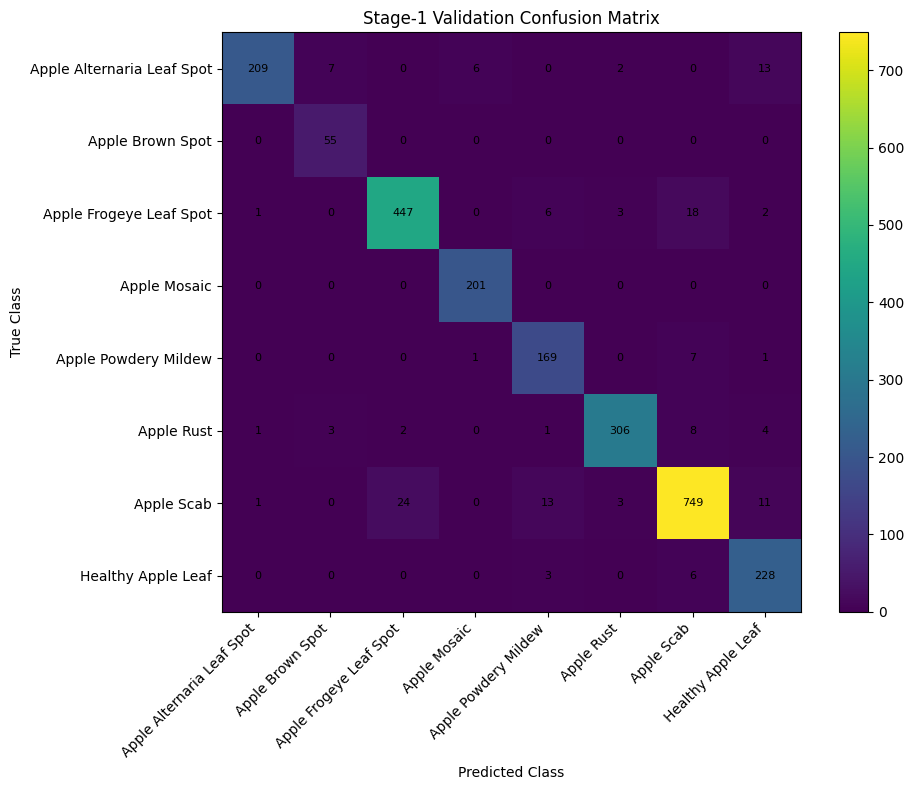


PASS: STAGE-1 VALIDATION EVALUATION COMPLETE


In [17]:
# ============================================================
# STAGE 1 — DETAILED VALIDATION EVALUATION
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)


model.eval()

all_targets = []
all_predictions = []


# ------------------------------------------------------------
# RUN VALIDATION SET
# ------------------------------------------------------------

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )


        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            outputs = model(images)


        predictions = outputs.argmax(
            dim=1
        )


        all_targets.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )


all_targets = np.array(all_targets)
all_predictions = np.array(all_predictions)


# ============================================================
# OVERALL METRICS
# ============================================================

stage1_val_accuracy = accuracy_score(
    all_targets,
    all_predictions
)

stage1_val_macro_f1 = f1_score(
    all_targets,
    all_predictions,
    average="macro",
    zero_division=0
)


print("=" * 80)
print("STAGE-1 BEST MODEL — VALIDATION RESULTS")
print("=" * 80)

print(
    f"Validation Accuracy : "
    f"{stage1_val_accuracy * 100:.2f}%"
)

print(
    f"Validation Macro-F1 : "
    f"{stage1_val_macro_f1:.4f}"
)


# ============================================================
# PER-CLASS REPORT
# ============================================================

print("\n" + "=" * 80)
print("PER-CLASS CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(
        all_targets,
        all_predictions,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    all_targets,
    all_predictions,
    labels=range(NUM_CLASSES)
)


fig, ax = plt.subplots(
    figsize=(10, 8)
)

im = ax.imshow(cm)

ax.set_xticks(
    range(NUM_CLASSES)
)

ax.set_yticks(
    range(NUM_CLASSES)
)

ax.set_xticklabels(
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    CLASS_NAMES
)

ax.set_xlabel(
    "Predicted Class"
)

ax.set_ylabel(
    "True Class"
)

ax.set_title(
    "Stage-1 Validation Confusion Matrix"
)


# Add values inside cells
for i in range(NUM_CLASSES):

    for j in range(NUM_CLASSES):

        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=8
        )


fig.colorbar(
    im,
    ax=ax
)

plt.tight_layout()
plt.show()


print(
    "\nPASS: STAGE-1 VALIDATION EVALUATION COMPLETE"
)


In [18]:
# ============================================================
# STAGE 2 — UNFREEZE ONLY RESNET50 LAYER4
# ============================================================

# First freeze the complete ResNet backbone
for param in model.backbone.parameters():
    param.requires_grad = False


# backbone[7] = ResNet50 layer4
for param in model.backbone[7].parameters():
    param.requires_grad = True


# ============================================================
# PARAMETER COUNTS
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

frozen_params = total_params - trainable_params


print("=" * 75)
print("STAGE 2 — PARAMETER CONFIGURATION")
print("=" * 75)

print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"Frozen parameters    : {frozen_params:,}")

print(
    f"Trainable percentage : "
    f"{100 * trainable_params / total_params:.2f}%"
)


# ============================================================
# CHECK MODULE STATUS
# ============================================================

def is_trainable(module):
    return any(
        p.requires_grad
        for p in module.parameters()
    )


print("\n" + "=" * 75)
print("RESNET50 STATUS")
print("=" * 75)

print(
    "conv1  :",
    "TRAINABLE" if is_trainable(model.backbone[0]) else "FROZEN"
)

print(
    "layer1 :",
    "TRAINABLE" if is_trainable(model.backbone[4]) else "FROZEN"
)

print(
    "layer2 :",
    "TRAINABLE" if is_trainable(model.backbone[5]) else "FROZEN"
)

print(
    "layer3 :",
    "TRAINABLE" if is_trainable(model.backbone[6]) else "FROZEN"
)

print(
    "layer4 :",
    "TRAINABLE" if is_trainable(model.backbone[7]) else "FROZEN"
)


print("\n" + "=" * 75)
print("HYBRID COMPONENTS")
print("=" * 75)

print(
    "Projection           :",
    "TRAINABLE" if is_trainable(model.projection) else "FROZEN"
)

print(
    "Positional embedding :",
    "TRAINABLE" if model.pos_embedding.requires_grad else "FROZEN"
)

print(
    "Transformer          :",
    "TRAINABLE" if is_trainable(model.transformer) else "FROZEN"
)

print(
    "Classifier           :",
    "TRAINABLE" if is_trainable(model.classifier) else "FROZEN"
)


# ============================================================
# FINAL CHECK
# ============================================================

earlier_resnet_frozen = all(
    not p.requires_grad
    for module in [
        model.backbone[0],
        model.backbone[1],
        model.backbone[4],
        model.backbone[5],
        model.backbone[6]
    ]
    for p in module.parameters()
)

layer4_trainable = all(
    p.requires_grad
    for p in model.backbone[7].parameters()
)


if (
    earlier_resnet_frozen
    and layer4_trainable
):

    print(
        "\nPASS: STAGE-2 PARAMETER CONFIGURATION IS CORRECT"
    )

else:

    print(
        "\nFAIL: CHECK PARAMETER CONFIGURATION"
    )

STAGE 2 — PARAMETER CONFIGURATION
Total parameters     : 30,892,104
Trainable parameters : 22,348,808
Frozen parameters    : 8,543,296
Trainable percentage : 72.34%

RESNET50 STATUS
conv1  : FROZEN
layer1 : FROZEN
layer2 : FROZEN
layer3 : FROZEN
layer4 : TRAINABLE

HYBRID COMPONENTS
Projection           : TRAINABLE
Positional embedding : TRAINABLE
Transformer          : TRAINABLE
Classifier           : TRAINABLE

PASS: STAGE-2 PARAMETER CONFIGURATION IS CORRECT


In [19]:
# ============================================================
# STAGE 2 — OPTIMIZER + SCHEDULER + AMP
# ============================================================

import torch
import torch.nn as nn


# ------------------------------------------------------------
# LOSS
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)


# ------------------------------------------------------------
# DIFFERENTIAL LEARNING RATES
# ------------------------------------------------------------

BACKBONE_LR = 1e-5
HYBRID_LR = 5e-5
WEIGHT_DECAY = 1e-4


# ResNet50 layer4 parameters
layer4_params = list(
    model.backbone[7].parameters()
)


# Everything trainable except layer4
layer4_param_ids = {
    id(p) for p in layer4_params
}

hybrid_params = [
    p
    for p in model.parameters()
    if p.requires_grad
    and id(p) not in layer4_param_ids
]


optimizer_stage2 = torch.optim.AdamW(
    [
        {
            "params": layer4_params,
            "lr": BACKBONE_LR
        },
        {
            "params": hybrid_params,
            "lr": HYBRID_LR
        }
    ],
    weight_decay=WEIGHT_DECAY
)


# ------------------------------------------------------------
# SCHEDULER
# ------------------------------------------------------------

scheduler_stage2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_stage2,
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=1e-7
)


# ------------------------------------------------------------
# NEW AMP SCALER FOR STAGE 2
# ------------------------------------------------------------

scaler_stage2 = torch.amp.GradScaler(
    "cuda"
)


# ------------------------------------------------------------
# TRAINING SETTINGS
# ------------------------------------------------------------

STAGE2_EPOCHS = 15

STAGE2_EARLY_STOPPING_PATIENCE = 5


# ------------------------------------------------------------
# VERIFY PARAMETER GROUPS
# ------------------------------------------------------------

layer4_count = sum(
    p.numel()
    for p in layer4_params
)

hybrid_count = sum(
    p.numel()
    for p in hybrid_params
)

optimizer_count = (
    layer4_count
    + hybrid_count
)

trainable_count = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print("=" * 75)
print("STAGE 2 — TRAINING CONFIGURATION")
print("=" * 75)

print("Loss                   : Weighted CrossEntropyLoss")
print("Optimizer              : AdamW")

print(
    "ResNet layer4 LR       :",
    BACKBONE_LR
)

print(
    "Hybrid components LR   :",
    HYBRID_LR
)

print(
    "Weight decay           :",
    WEIGHT_DECAY
)

print(
    "Maximum epochs         :",
    STAGE2_EPOCHS
)

print(
    "Early-stop patience    :",
    STAGE2_EARLY_STOPPING_PATIENCE
)

print(
    "Scheduler              : ReduceLROnPlateau"
)

print(
    "Mixed precision        : ENABLED"
)


print("\n" + "=" * 75)
print("PARAMETER GROUPS")
print("=" * 75)

print(
    f"ResNet layer4 params    : {layer4_count:,}"
)

print(
    f"Hybrid params           : {hybrid_count:,}"
)

print(
    f"Optimizer total         : {optimizer_count:,}"
)

print(
    f"Model trainable total   : {trainable_count:,}"
)


if optimizer_count == trainable_count:

    print(
        "\nPASS: STAGE-2 OPTIMIZER PARAMETER GROUPS ARE CORRECT"
    )

else:

    print(
        "\nFAIL: OPTIMIZER PARAMETER COUNT MISMATCH"
    )


print("\nLearning-rate groups:")

for i, group in enumerate(
    optimizer_stage2.param_groups
):

    print(
        f"Group {i}: "
        f"LR = {group['lr']:.2e}"
    )

STAGE 2 — TRAINING CONFIGURATION
Loss                   : Weighted CrossEntropyLoss
Optimizer              : AdamW
ResNet layer4 LR       : 1e-05
Hybrid components LR   : 5e-05
Weight decay           : 0.0001
Maximum epochs         : 15
Early-stop patience    : 5
Scheduler              : ReduceLROnPlateau
Mixed precision        : ENABLED

PARAMETER GROUPS
ResNet layer4 params    : 14,964,736
Hybrid params           : 7,384,072
Optimizer total         : 22,348,808
Model trainable total   : 22,348,808

PASS: STAGE-2 OPTIMIZER PARAMETER GROUPS ARE CORRECT

Learning-rate groups:
Group 0: LR = 1.00e-05
Group 1: LR = 5.00e-05


In [20]:
# ============================================================
# STAGE 2 — TRAIN ONE EPOCH
# ============================================================

def train_one_epoch_stage2(
    model,
    loader,
    criterion,
    optimizer,
    scaler,
    device
):

    # Put complete model in training mode first
    model.train()


    # --------------------------------------------------------
    # FROZEN RESNET PORTION
    # --------------------------------------------------------
    # Keep frozen modules in eval mode so their BatchNorm
    # running statistics do not change.
    #
    # backbone:
    # 0 = conv1
    # 1 = bn1
    # 2 = relu
    # 3 = maxpool
    # 4 = layer1
    # 5 = layer2
    # 6 = layer3
    # 7 = layer4  <-- remains TRAIN mode
    # --------------------------------------------------------

    for idx in range(7):
        model.backbone[idx].eval()

    model.backbone[7].train()


    running_loss = 0.0

    all_predictions = []
    all_targets = []


    progress_bar = tqdm(
        loader,
        desc="Stage-2 Training",
        leave=False
    )


    for images, labels in progress_bar:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        # ----------------------------------------------------
        # FORWARD PASS — AMP
        # ----------------------------------------------------

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )


        # ----------------------------------------------------
        # BACKPROPAGATION
        # ----------------------------------------------------

        scaler.scale(
            loss
        ).backward()

        scaler.step(
            optimizer
        )

        scaler.update()


        # ----------------------------------------------------
        # METRICS
        # ----------------------------------------------------

        batch_size = images.size(0)

        running_loss += (
            loss.item() * batch_size
        )


        predictions = outputs.argmax(
            dim=1
        )


        all_predictions.extend(
            predictions.detach().cpu().numpy()
        )

        all_targets.extend(
            labels.detach().cpu().numpy()
        )


        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )


    # ========================================================
    # EPOCH METRICS
    # ========================================================

    epoch_loss = (
        running_loss
        / len(loader.dataset)
    )

    all_predictions = np.array(
        all_predictions
    )

    all_targets = np.array(
        all_targets
    )


    epoch_accuracy = (
        all_predictions == all_targets
    ).mean()


    epoch_macro_f1 = f1_score(
        all_targets,
        all_predictions,
        average="macro",
        zero_division=0
    )


    return (
        epoch_loss,
        epoch_accuracy,
        epoch_macro_f1
    )


print("=" * 75)
print("STAGE-2 TRAINING FUNCTION CREATED")
print("=" * 75)

print("conv1 → layer3       : FROZEN / EVAL")
print("layer4               : TRAINABLE / TRAIN")
print("Projection           : TRAINABLE")
print("Transformer          : TRAINABLE")
print("Classifier           : TRAINABLE")
print("Mixed precision      : ENABLED")
print("Macro-F1 tracking    : ENABLED")

print(
    "\nPASS: STAGE-2 TRAINING FUNCTION READY"
)

STAGE-2 TRAINING FUNCTION CREATED
conv1 → layer3       : FROZEN / EVAL
layer4               : TRAINABLE / TRAIN
Projection           : TRAINABLE
Transformer          : TRAINABLE
Classifier           : TRAINABLE
Mixed precision      : ENABLED
Macro-F1 tracking    : ENABLED

PASS: STAGE-2 TRAINING FUNCTION READY


In [21]:
# ============================================================
# STAGE 2 — FINE-TUNING LOOP
# ============================================================

from pathlib import Path
import time
import torch


# ------------------------------------------------------------
# CHECKPOINT
# ------------------------------------------------------------

STAGE2_BEST_PATH = (
    CHECKPOINT_DIR /
    "resnet50_attention_stage2_best.pth"
)


# ------------------------------------------------------------
# HISTORY
# ------------------------------------------------------------

stage2_history = {
    "train_loss": [],
    "train_accuracy": [],
    "train_f1": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_f1": [],
    "layer4_lr": [],
    "hybrid_lr": []
}


best_stage2_val_f1 = -1.0
best_stage2_epoch = 0

epochs_without_improvement = 0


print("=" * 75)
print("STARTING STAGE-2 FINE-TUNING")
print("=" * 75)

print(
    "Stage-1 baseline F1   :",
    f"{stage1_val_macro_f1:.4f}"
)

print(
    "Maximum epochs        :",
    STAGE2_EPOCHS
)

print(
    "Early-stop patience   :",
    STAGE2_EARLY_STOPPING_PATIENCE
)

print(
    "Layer4 initial LR     :",
    BACKBONE_LR
)

print(
    "Hybrid initial LR     :",
    HYBRID_LR
)

print(
    "Checkpoint metric     : Validation Macro-F1"
)

print(
    "Checkpoint path       :",
    STAGE2_BEST_PATH
)

print("=" * 75)


stage2_start_time = time.time()


# ============================================================
# TRAIN
# ============================================================

for epoch in range(
    1,
    STAGE2_EPOCHS + 1
):

    epoch_start = time.time()


    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    train_loss, train_acc, train_f1 = (
        train_one_epoch_stage2(
            model=model,
            loader=train_loader,
            criterion=criterion,
            optimizer=optimizer_stage2,
            scaler=scaler_stage2,
            device=DEVICE
        )
    )


    # --------------------------------------------------------
    # VALIDATE
    # --------------------------------------------------------

    val_loss, val_acc, val_f1 = (
        validate_one_epoch(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=DEVICE
        )
    )


    # --------------------------------------------------------
    # SCHEDULER
    # --------------------------------------------------------

    scheduler_stage2.step(
        val_loss
    )


    layer4_lr = (
        optimizer_stage2
        .param_groups[0]["lr"]
    )

    hybrid_lr = (
        optimizer_stage2
        .param_groups[1]["lr"]
    )


    # --------------------------------------------------------
    # HISTORY
    # --------------------------------------------------------

    stage2_history["train_loss"].append(
        train_loss
    )

    stage2_history["train_accuracy"].append(
        train_acc
    )

    stage2_history["train_f1"].append(
        train_f1
    )

    stage2_history["val_loss"].append(
        val_loss
    )

    stage2_history["val_accuracy"].append(
        val_acc
    )

    stage2_history["val_f1"].append(
        val_f1
    )

    stage2_history["layer4_lr"].append(
        layer4_lr
    )

    stage2_history["hybrid_lr"].append(
        hybrid_lr
    )


    # --------------------------------------------------------
    # BEST STAGE-2 CHECKPOINT
    # --------------------------------------------------------

    improved = (
        val_f1 > best_stage2_val_f1
    )


    if improved:

        best_stage2_val_f1 = val_f1
        best_stage2_epoch = epoch

        epochs_without_improvement = 0


        torch.save(
            {
                "stage": 2,

                "epoch": epoch,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer_stage2.state_dict(),

                "scheduler_state_dict":
                    scheduler_stage2.state_dict(),

                "scaler_state_dict":
                    scaler_stage2.state_dict(),

                "best_val_f1":
                    best_stage2_val_f1,

                "stage1_baseline_f1":
                    stage1_val_macro_f1,

                "class_names":
                    CLASS_NAMES,

                "class_to_idx":
                    train_dataset.class_to_idx,

                "history":
                    stage2_history
            },

            STAGE2_BEST_PATH
        )


    else:

        epochs_without_improvement += 1


    # --------------------------------------------------------
    # OUTPUT
    # --------------------------------------------------------

    epoch_time = (
        time.time()
        - epoch_start
    )


    print(
        f"\nEpoch {epoch:02d}/{STAGE2_EPOCHS}"
    )

    print(
        f"Train Loss : {train_loss:.4f} | "
        f"Acc: {train_acc*100:.2f}% | "
        f"Macro-F1: {train_f1:.4f}"
    )

    print(
        f"Val   Loss : {val_loss:.4f} | "
        f"Acc: {val_acc*100:.2f}% | "
        f"Macro-F1: {val_f1:.4f}"
    )

    print(
        f"LR layer4  : {layer4_lr:.2e}"
    )

    print(
        f"LR hybrid  : {hybrid_lr:.2e}"
    )

    print(
        f"Time       : {epoch_time/60:.2f} min"
    )


    if improved:

        print(
            "Checkpoint : SAVED — "
            "new best Stage-2 Macro-F1"
        )

    else:

        print(
            "Checkpoint : no improvement "
            f"({epochs_without_improvement}/"
            f"{STAGE2_EARLY_STOPPING_PATIENCE})"
        )


    # Compare with Stage 1
    difference = (
        val_f1
        - stage1_val_macro_f1
    )

    print(
        f"vs Stage 1 : "
        f"{difference:+.4f} Macro-F1"
    )

    print("-" * 75)


    # --------------------------------------------------------
    # EARLY STOPPING
    # --------------------------------------------------------

    if (
        epochs_without_improvement
        >= STAGE2_EARLY_STOPPING_PATIENCE
    ):

        print(
            "\nEARLY STOPPING TRIGGERED"
        )

        break


# ============================================================
# COMPLETE
# ============================================================

stage2_total_time = (
    time.time()
    - stage2_start_time
)


print("\n" + "=" * 75)
print("STAGE-2 FINE-TUNING COMPLETE")
print("=" * 75)

print(
    "Best Stage-2 epoch    :",
    best_stage2_epoch
)

print(
    "Best Stage-2 Val F1   :",
    f"{best_stage2_val_f1:.4f}"
)

print(
    "Stage-1 Val F1        :",
    f"{stage1_val_macro_f1:.4f}"
)

print(
    "Improvement           :",
    f"{best_stage2_val_f1 - stage1_val_macro_f1:+.4f}"
)

print(
    "Total training time   :",
    f"{stage2_total_time/60:.2f} min"
)

print(
    "Best checkpoint       :",
    STAGE2_BEST_PATH
)

STARTING STAGE-2 FINE-TUNING
Stage-1 baseline F1   : 0.9381
Maximum epochs        : 15
Early-stop patience   : 5
Layer4 initial LR     : 1e-05
Hybrid initial LR     : 5e-05
Checkpoint metric     : Validation Macro-F1
Checkpoint path       : /content/drive/MyDrive/final_year_project/Apple/checkpoints/resnet50_attention_stage2_best.pth


Stage-2 Training:   0%|          | 0/367 [00:00<?, ?it/s]

Validation:   0%|          | 0/79 [00:00<?, ?it/s]


Epoch 01/15
Train Loss : 0.2508 | Acc: 89.28% | Macro-F1: 0.8991
Val   Loss : 0.2258 | Acc: 92.83% | Macro-F1: 0.9300
LR layer4  : 1.00e-05
LR hybrid  : 5.00e-05
Time       : 3.43 min
Checkpoint : SAVED — new best Stage-2 Macro-F1
vs Stage 1 : -0.0081 Macro-F1
---------------------------------------------------------------------------


Stage-2 Training:   0%|          | 0/367 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/79 [00:00<?, ?it/s]


Epoch 13/15
Train Loss : 0.0287 | Acc: 98.52% | Macro-F1: 0.9887
Val   Loss : 0.1273 | Acc: 96.18% | Macro-F1: 0.9650
LR layer4  : 5.00e-06
LR hybrid  : 2.50e-05
Time       : 3.22 min
Checkpoint : no improvement (4/5)
vs Stage 1 : +0.0269 Macro-F1
---------------------------------------------------------------------------


Stage-2 Training:   0%|          | 0/367 [00:00<?, ?it/s]

Validation:   0%|          | 0/79 [00:00<?, ?it/s]


Epoch 14/15
Train Loss : 0.0289 | Acc: 98.47% | Macro-F1: 0.9878
Val   Loss : 0.1340 | Acc: 95.94% | Macro-F1: 0.9633
LR layer4  : 2.50e-06
LR hybrid  : 1.25e-05
Time       : 3.18 min
Checkpoint : no improvement (5/5)
vs Stage 1 : +0.0252 Macro-F1
---------------------------------------------------------------------------

EARLY STOPPING TRIGGERED

STAGE-2 FINE-TUNING COMPLETE
Best Stage-2 epoch    : 9
Best Stage-2 Val F1   : 0.9722
Stage-1 Val F1        : 0.9381
Improvement           : +0.0341
Total training time   : 45.46 min
Best checkpoint       : /content/drive/MyDrive/final_year_project/Apple/checkpoints/resnet50_attention_stage2_best.pth


BEST STAGE-2 CHECKPOINT RESTORED
Epoch             : 9
Best validation F1: 0.9721659191172167

STAGE-2 BEST MODEL — VALIDATION RESULTS
Validation Accuracy : 97.01%
Validation Macro-F1 : 0.9722

PER-CLASS CLASSIFICATION REPORT
                            precision    recall  f1-score   support

Apple Alternaria Leaf Spot     0.9787    0.9705    0.9746       237
          Apple Brown Spot     0.9483    1.0000    0.9735        55
   Apple Frogeye Leaf Spot     0.9683    0.9602    0.9642       477
              Apple Mosaic     0.9901    1.0000    0.9950       201
      Apple Powdery Mildew     0.9600    0.9438    0.9518       178
                Apple Rust     0.9779    0.9538    0.9657       325
                Apple Scab     0.9640    0.9700    0.9670       801
        Healthy Apple Leaf     0.9713    1.0000    0.9854       237

                  accuracy                         0.9701      2511
                 macro avg     0.9698    0.9748    0.9722      2511
              weighted a

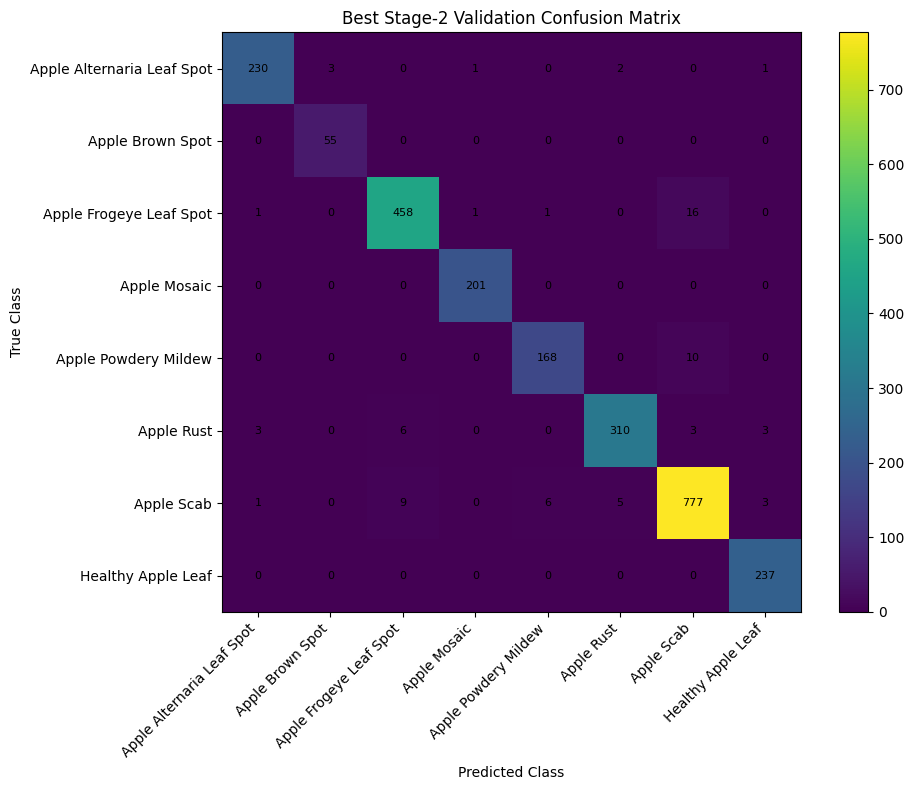


PASS: BEST STAGE-2 VALIDATION EVALUATION COMPLETE


In [22]:
# ============================================================
# STEP 32 — LOAD BEST STAGE-2 MODEL + DETAILED VALIDATION
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# ============================================================
# 1. LOAD BEST STAGE-2 CHECKPOINT
# ============================================================

checkpoint_stage2 = torch.load(
    STAGE2_BEST_PATH,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(
    checkpoint_stage2["model_state_dict"]
)

model.eval()


print("=" * 80)
print("BEST STAGE-2 CHECKPOINT RESTORED")
print("=" * 80)

print(
    "Epoch             :",
    checkpoint_stage2["epoch"]
)

print(
    "Best validation F1:",
    checkpoint_stage2["best_val_f1"]
)


# ============================================================
# 2. RUN VALIDATION SET
# ============================================================

all_targets = []
all_predictions = []


with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )


        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            outputs = model(images)


        predictions = outputs.argmax(
            dim=1
        )


        all_targets.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )


all_targets = np.array(all_targets)
all_predictions = np.array(all_predictions)


# ============================================================
# 3. OVERALL METRICS
# ============================================================

stage2_val_accuracy = accuracy_score(
    all_targets,
    all_predictions
)

stage2_val_macro_f1 = f1_score(
    all_targets,
    all_predictions,
    average="macro",
    zero_division=0
)


print("\n" + "=" * 80)
print("STAGE-2 BEST MODEL — VALIDATION RESULTS")
print("=" * 80)

print(
    f"Validation Accuracy : "
    f"{stage2_val_accuracy * 100:.2f}%"
)

print(
    f"Validation Macro-F1 : "
    f"{stage2_val_macro_f1:.4f}"
)


# ============================================================
# 4. PER-CLASS REPORT
# ============================================================

print("\n" + "=" * 80)
print("PER-CLASS CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(
        all_targets,
        all_predictions,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 5. CONFUSION MATRIX
# ============================================================

cm_stage2 = confusion_matrix(
    all_targets,
    all_predictions,
    labels=range(NUM_CLASSES)
)


fig, ax = plt.subplots(
    figsize=(10, 8)
)

im = ax.imshow(
    cm_stage2
)

ax.set_xticks(
    range(NUM_CLASSES)
)

ax.set_yticks(
    range(NUM_CLASSES)
)

ax.set_xticklabels(
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    CLASS_NAMES
)

ax.set_xlabel(
    "Predicted Class"
)

ax.set_ylabel(
    "True Class"
)

ax.set_title(
    "Best Stage-2 Validation Confusion Matrix"
)


for i in range(NUM_CLASSES):

    for j in range(NUM_CLASSES):

        ax.text(
            j,
            i,
            cm_stage2[i, j],
            ha="center",
            va="center",
            fontsize=8
        )


fig.colorbar(
    im,
    ax=ax
)

plt.tight_layout()
plt.show()


print(
    "\nPASS: BEST STAGE-2 VALIDATION EVALUATION COMPLETE"
)

FINAL SELECTED MODEL — INTERNAL TEST
Accuracy : 96.22%
Macro-F1 : 0.9676

INTERNAL-TEST CLASSIFICATION REPORT
                            precision    recall  f1-score   support

Apple Alternaria Leaf Spot     0.9829    0.9787    0.9808       235
          Apple Brown Spot     0.9821    1.0000    0.9910        55
   Apple Frogeye Leaf Spot     0.9621    0.9581    0.9601       477
              Apple Mosaic     0.9804    0.9950    0.9877       201
      Apple Powdery Mildew     1.0000    0.9266    0.9619       177
                Apple Rust     0.9619    0.9323    0.9469       325
                Apple Scab     0.9543    0.9614    0.9579       804
        Healthy Apple Leaf     0.9246    0.9873    0.9549       236

                  accuracy                         0.9622      2510
                 macro avg     0.9685    0.9674    0.9676      2510
              weighted avg     0.9626    0.9622    0.9621      2510



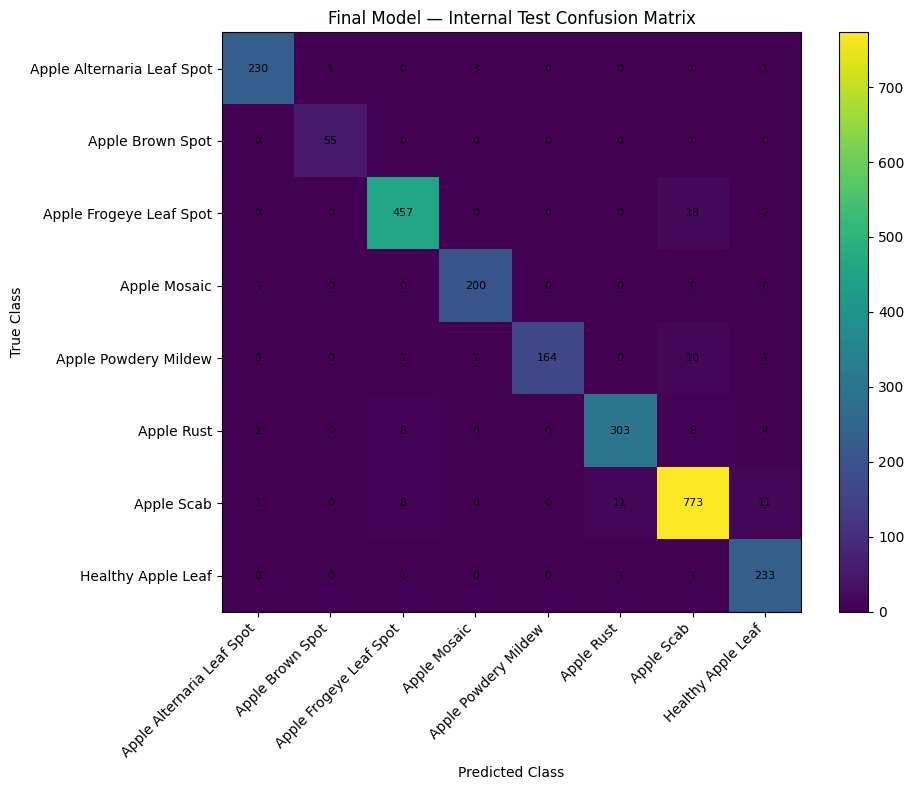


PASS: FINAL INTERNAL-TEST EVALUATION COMPLETE


In [23]:
# ============================================================
# STEP 33 — FINAL INTERNAL-TEST EVALUATION
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# ------------------------------------------------------------
# Ensure BEST Stage-2 model is loaded
# ------------------------------------------------------------

model.load_state_dict(
    checkpoint_stage2["model_state_dict"]
)

model.eval()


internal_targets = []
internal_predictions = []


# ============================================================
# RUN INTERNAL TEST
# ============================================================

with torch.no_grad():

    for images, labels in internal_test_loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )


        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            outputs = model(images)


        predictions = outputs.argmax(
            dim=1
        )


        internal_targets.extend(
            labels.cpu().numpy()
        )

        internal_predictions.extend(
            predictions.cpu().numpy()
        )


internal_targets = np.array(
    internal_targets
)

internal_predictions = np.array(
    internal_predictions
)


# ============================================================
# OVERALL METRICS
# ============================================================

internal_accuracy = accuracy_score(
    internal_targets,
    internal_predictions
)

internal_macro_f1 = f1_score(
    internal_targets,
    internal_predictions,
    average="macro",
    zero_division=0
)


print("=" * 80)
print("FINAL SELECTED MODEL — INTERNAL TEST")
print("=" * 80)

print(
    f"Accuracy : "
    f"{internal_accuracy * 100:.2f}%"
)

print(
    f"Macro-F1 : "
    f"{internal_macro_f1:.4f}"
)


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 80)
print("INTERNAL-TEST CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(
        internal_targets,
        internal_predictions,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# CONFUSION MATRIX
# ============================================================

cm_internal = confusion_matrix(
    internal_targets,
    internal_predictions,
    labels=range(NUM_CLASSES)
)


fig, ax = plt.subplots(
    figsize=(10, 8)
)

im = ax.imshow(
    cm_internal
)

ax.set_xticks(
    range(NUM_CLASSES)
)

ax.set_yticks(
    range(NUM_CLASSES)
)

ax.set_xticklabels(
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    CLASS_NAMES
)

ax.set_xlabel(
    "Predicted Class"
)

ax.set_ylabel(
    "True Class"
)

ax.set_title(
    "Final Model — Internal Test Confusion Matrix"
)


for i in range(NUM_CLASSES):

    for j in range(NUM_CLASSES):

        ax.text(
            j,
            i,
            cm_internal[i, j],
            ha="center",
            va="center",
            fontsize=8
        )


fig.colorbar(
    im,
    ax=ax
)

plt.tight_layout()
plt.show()


print(
    "\nPASS: FINAL INTERNAL-TEST EVALUATION COMPLETE"
)

In [25]:
# ============================================================
# STEP 34 — CORRECT EXTERNAL -> MAIN LABEL MAPPING
# ============================================================

print("=" * 80)
print("EXTERNAL -> MAIN MODEL LABEL MAPPING")
print("=" * 80)


# ------------------------------------------------------------
# External classes already use standardized names
# ------------------------------------------------------------

external_to_main_name = {

    "Apple Alternaria Leaf Spot":
        "Apple Alternaria Leaf Spot",

    "Apple Mosaic":
        "Apple Mosaic",

    "Apple Powdery Mildew":
        "Apple Powdery Mildew"
}


# ------------------------------------------------------------
# BUILD NUMERIC MAPPING
# ------------------------------------------------------------

external_idx_to_main_idx = {}


for external_name, main_name in (
    external_to_main_name.items()
):

    if external_name not in external_raw_dataset.class_to_idx:

        raise ValueError(
            f"External class not found: {external_name}"
        )

    if main_name not in train_dataset.class_to_idx:

        raise ValueError(
            f"Main model class not found: {main_name}"
        )


    external_idx = (
        external_raw_dataset
        .class_to_idx[external_name]
    )

    main_idx = (
        train_dataset
        .class_to_idx[main_name]
    )


    external_idx_to_main_idx[
        external_idx
    ] = main_idx


# ------------------------------------------------------------
# DISPLAY MAPPING
# ------------------------------------------------------------

for external_idx, main_idx in sorted(
    external_idx_to_main_idx.items()
):

    external_name = (
        external_raw_dataset.classes[
            external_idx
        ]
    )

    main_name = CLASS_NAMES[
        main_idx
    ]


    print(
        f"\nExternal {external_idx}: "
        f"{external_name}"
    )

    print("        ↓")

    print(
        f"Model    {main_idx}: "
        f"{main_name}"
    )


# ------------------------------------------------------------
# SANITY CHECKS
# ------------------------------------------------------------

assert len(external_raw_dataset) == 410

assert len(external_idx_to_main_idx) == 3

assert external_idx_to_main_idx == {
    0: 0,
    1: 3,
    2: 4
}


print("\n" + "=" * 80)

print(
    "PASS: EXTERNAL LABEL MAPPING VERIFIED"
)

EXTERNAL -> MAIN MODEL LABEL MAPPING

External 0: Apple Alternaria Leaf Spot
        ↓
Model    0: Apple Alternaria Leaf Spot

External 1: Apple Mosaic
        ↓
Model    3: Apple Mosaic

External 2: Apple Powdery Mildew
        ↓
Model    4: Apple Powdery Mildew

PASS: EXTERNAL LABEL MAPPING VERIFIED


EXTERNAL TEST LOADER
Images       : 410
Batches      : 13
True classes : ['Apple Alternaria Leaf Spot', 'Apple Mosaic', 'Apple Powdery Mildew']
Model outputs: 8 classes

FINAL MODEL — EXTERNAL TEST RESULTS
External Accuracy : 58.05%
External Macro-F1 : 0.6307

EXTERNAL CLASSIFICATION REPORT
                            precision    recall  f1-score   support

Apple Alternaria Leaf Spot     0.7778    0.4308    0.5545        65
              Apple Mosaic     0.5530    0.6822    0.6109       107
      Apple Powdery Mildew     0.9856    0.5756    0.7268       238

                 micro avg     0.7752    0.5805    0.6639       410
                 macro avg     0.7721    0.5629    0.6307       410
              weighted avg     0.8398    0.5805    0.6692       410



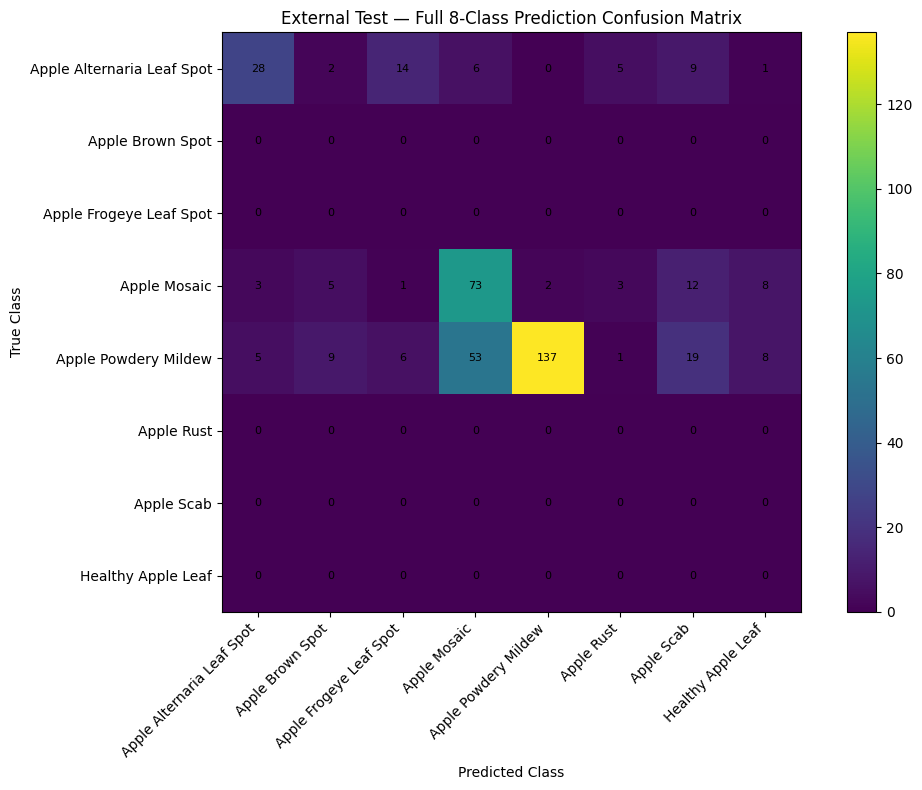


EXTERNAL PREDICTION DISTRIBUTION
Apple Alternaria Leaf Spot    :   36
Apple Brown Spot              :   16
Apple Frogeye Leaf Spot       :   21
Apple Mosaic                  :  132
Apple Powdery Mildew          :  139
Apple Rust                    :    9
Apple Scab                    :   40
Healthy Apple Leaf            :   17

CROSS-DATASET ERROR CHECK
Predictions into classes absent from external ground truth: 103
Percentage: 25.12%

PASS: EXTERNAL TEST EVALUATION COMPLETE


In [26]:
# ============================================================
# STEP 35 — EXTERNAL TEST EVALUATION
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# ============================================================
# 1. WRAPPER TO REMAP EXTERNAL LABELS
# ============================================================

class ExternalRemappedDataset(Dataset):

    def __init__(
        self,
        dataset,
        label_mapping
    ):

        self.dataset = dataset
        self.label_mapping = label_mapping


    def __len__(self):

        return len(self.dataset)


    def __getitem__(
        self,
        index
    ):

        image, external_label = (
            self.dataset[index]
        )

        main_label = (
            self.label_mapping[
                external_label
            ]
        )

        return image, main_label


# ============================================================
# 2. CREATE REMAPPED DATASET
# ============================================================

external_dataset = ExternalRemappedDataset(
    dataset=external_raw_dataset,
    label_mapping=external_idx_to_main_idx
)


external_loader = DataLoader(
    external_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)


print("=" * 80)
print("EXTERNAL TEST LOADER")
print("=" * 80)

print(
    "Images       :",
    len(external_dataset)
)

print(
    "Batches      :",
    len(external_loader)
)

print(
    "True classes :",
    [
        "Apple Alternaria Leaf Spot",
        "Apple Mosaic",
        "Apple Powdery Mildew"
    ]
)

print(
    "Model outputs:",
    NUM_CLASSES,
    "classes"
)


# ============================================================
# 3. ENSURE FINAL BEST MODEL IS LOADED
# ============================================================

model.load_state_dict(
    checkpoint_stage2["model_state_dict"]
)

model.eval()


# ============================================================
# 4. RUN EXTERNAL TEST
# ============================================================

external_targets = []
external_predictions = []


with torch.no_grad():

    for images, labels in external_loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )


        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            outputs = model(images)


        predictions = outputs.argmax(
            dim=1
        )


        external_targets.extend(
            labels.cpu().numpy()
        )

        external_predictions.extend(
            predictions.cpu().numpy()
        )


external_targets = np.array(
    external_targets
)

external_predictions = np.array(
    external_predictions
)


# ============================================================
# 5. OVERALL EXTERNAL METRICS
# ============================================================

external_accuracy = accuracy_score(
    external_targets,
    external_predictions
)


# Macro-F1 across ONLY the 3 classes actually present as
# ground-truth classes in the external dataset.
external_true_class_indices = [
    train_dataset.class_to_idx[
        "Apple Alternaria Leaf Spot"
    ],

    train_dataset.class_to_idx[
        "Apple Mosaic"
    ],

    train_dataset.class_to_idx[
        "Apple Powdery Mildew"
    ]
]


external_macro_f1 = f1_score(
    external_targets,
    external_predictions,
    labels=external_true_class_indices,
    average="macro",
    zero_division=0
)


print("\n" + "=" * 80)
print("FINAL MODEL — EXTERNAL TEST RESULTS")
print("=" * 80)

print(
    f"External Accuracy : "
    f"{external_accuracy * 100:.2f}%"
)

print(
    f"External Macro-F1 : "
    f"{external_macro_f1:.4f}"
)


# ============================================================
# 6. REPORT FOR THE 3 TRUE EXTERNAL CLASSES
# ============================================================

external_true_class_names = [
    CLASS_NAMES[i]
    for i in external_true_class_indices
]


print("\n" + "=" * 80)
print("EXTERNAL CLASSIFICATION REPORT")
print("=" * 80)


print(
    classification_report(
        external_targets,
        external_predictions,
        labels=external_true_class_indices,
        target_names=external_true_class_names,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 7. FULL 8-CLASS CONFUSION MATRIX
# ============================================================

cm_external = confusion_matrix(
    external_targets,
    external_predictions,
    labels=range(NUM_CLASSES)
)


fig, ax = plt.subplots(
    figsize=(11, 8)
)

im = ax.imshow(
    cm_external
)

ax.set_xticks(
    range(NUM_CLASSES)
)

ax.set_yticks(
    range(NUM_CLASSES)
)

ax.set_xticklabels(
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    CLASS_NAMES
)

ax.set_xlabel(
    "Predicted Class"
)

ax.set_ylabel(
    "True Class"
)

ax.set_title(
    "External Test — Full 8-Class Prediction Confusion Matrix"
)


for i in range(NUM_CLASSES):

    for j in range(NUM_CLASSES):

        ax.text(
            j,
            i,
            cm_external[i, j],
            ha="center",
            va="center",
            fontsize=8
        )


fig.colorbar(
    im,
    ax=ax
)

plt.tight_layout()
plt.show()


# ============================================================
# 8. PREDICTION DISTRIBUTION
# ============================================================

print("\n" + "=" * 80)
print("EXTERNAL PREDICTION DISTRIBUTION")
print("=" * 80)


unique_preds, pred_counts = np.unique(
    external_predictions,
    return_counts=True
)


for class_idx in range(NUM_CLASSES):

    count = (
        pred_counts[
            np.where(
                unique_preds == class_idx
            )[0][0]
        ]
        if class_idx in unique_preds
        else 0
    )


    print(
        f"{CLASS_NAMES[class_idx]:30s}: "
        f"{count:4d}"
    )


# ============================================================
# 9. COUNT OUT-OF-EXTERNAL-CLASS PREDICTIONS
# ============================================================

external_true_class_set = set(
    external_true_class_indices
)


outside_predictions = sum(
    pred not in external_true_class_set
    for pred in external_predictions
)


print("\n" + "=" * 80)
print("CROSS-DATASET ERROR CHECK")
print("=" * 80)

print(
    "Predictions into classes absent "
    "from external ground truth:",
    outside_predictions
)

print(
    "Percentage:",
    f"{100 * outside_predictions / len(external_dataset):.2f}%"
)


print(
    "\nPASS: EXTERNAL TEST EVALUATION COMPLETE"
)

APPLE LEAF DISEASE PREDICTION

Upload an apple leaf image:


Saving AppleScab01sm.jpg to AppleScab01sm.jpg


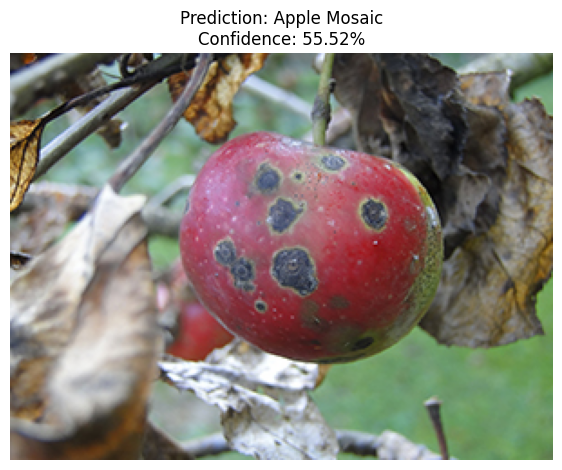


File       : AppleScab01sm.jpg
Prediction : Apple Mosaic
Confidence : 55.52%

All class probabilities:

Apple Mosaic                   :  55.53%
Apple Rust                     :  41.09%
Apple Scab                     :   1.65%
Apple Frogeye Leaf Spot        :   0.94%
Healthy Apple Leaf             :   0.60%
Apple Alternaria Leaf Spot     :   0.13%
Apple Brown Spot               :   0.08%
Apple Powdery Mildew           :   0.01%


In [48]:
# ============================================================
# STEP 36 — UPLOAD IMAGE AND PREDICT
# ============================================================

from google.colab import files
from PIL import Image

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import io


# ============================================================
# PREDICTION FUNCTION
# ============================================================

def predict_apple_leaf(image):

    model.eval()

    # Same preprocessing used for validation/test
    image_tensor = eval_transform(image)

    image_tensor = image_tensor.unsqueeze(0).to(
        DEVICE
    )

    with torch.no_grad():

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            outputs = model(image_tensor)

        probabilities = F.softmax(
            outputs,
            dim=1
        )[0]


    predicted_idx = probabilities.argmax().item()

    predicted_class = CLASS_NAMES[
        predicted_idx
    ]

    confidence = probabilities[
        predicted_idx
    ].item()


    return (
        predicted_class,
        confidence,
        probabilities.cpu().numpy()
    )


# ============================================================
# UPLOAD IMAGE
# ============================================================

print("=" * 70)
print("APPLE LEAF DISEASE PREDICTION")
print("=" * 70)

print("\nUpload an apple leaf image:")

uploaded = files.upload()


# ============================================================
# PROCESS EACH UPLOADED IMAGE
# ============================================================

for filename, file_data in uploaded.items():

    image = Image.open(
        io.BytesIO(file_data)
    ).convert("RGB")


    predicted_class, confidence, probabilities = (
        predict_apple_leaf(image)
    )


    # --------------------------------------------------------
    # SHOW IMAGE
    # --------------------------------------------------------

    plt.figure(
        figsize=(7, 6)
    )

    plt.imshow(image)

    plt.axis("off")

    plt.title(
        f"Prediction: {predicted_class}\n"
        f"Confidence: {confidence * 100:.2f}%"
    )

    plt.show()


    # --------------------------------------------------------
    # RESULT
    # --------------------------------------------------------

    print("\n" + "=" * 70)

    print(
        f"File       : {filename}"
    )

    print(
        f"Prediction : {predicted_class}"
    )

    print(
        f"Confidence : {confidence * 100:.2f}%"
    )

    print("=" * 70)


    # --------------------------------------------------------
    # ALL CLASS PROBABILITIES
    # --------------------------------------------------------

    print("\nAll class probabilities:\n")


    sorted_indices = probabilities.argsort()[::-1]


    for idx in sorted_indices:

        print(
            f"{CLASS_NAMES[idx]:30s} "
            f": {probabilities[idx] * 100:6.2f}%"
        )